##### Full Multi-Modal Model — ESM + Signal-Aware Boltz Hamiltonian (v2)
##### Architecture:
- ESM embeddings → bilinear compression → MLP expander → z_raw (unconstrained)
- Signal-aware Boltz latent (theta, 6528-dim) → deterministic Z* construction (frozen)
- theta = [A_diag(d), B_diag(d), C_diag(d), A_U(d×r), A_V(d×r), B_U(d×r), B_V(d×r), C_U(d×r), C_V(d×r)]
- Z* = [[I+A, I+C], [I+C^T, I+B]] with diagonal + low-rank blocks
- VICReg var/cov on z_raw, Hamiltonian on normalised ê with per-sample Z*
- Early stopping on val AUROC
- Per-epoch: H histogram, eT·ePH histogram, cross-reactivity boxplot
##### Cross-reactivity analysis:
- For positive pairs: group TCRs by peptide identity
- Compare cosine distance eT·ePH for same-peptide TCRs vs random positive pairs
- Track this separation over training epochs


In [1]:
# imports
import time
import esm
import pandas as pd
import torch
from torch import Tensor
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR
from torch.nn.utils.rnn import pad_sequence
from torch.amp import autocast
from torch.cuda.amp import GradScaler
import copy
from datetime import datetime

import sys
import os
import time
import math
import random
import pickle
import subprocess
import gc
from pathlib import Path
from typing import List, Tuple

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from IPython.display import display, update_display

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ESM imports
from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein, LogitsConfig, ESMProteinTensor
from esm.models.esmc import _BatchedESMProteinTensor

# Tokenizer imports
from tokenizers import Tokenizer
from tokenizers.models import WordPiece
from tokenizers import normalizers
from tokenizers.normalizers import NFD, Lowercase, StripAccents
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import WordPieceTrainer
from tokenizers import decoders

# PEFT imports
from peft import get_peft_model, LoraConfig, TaskType
from peft.tuners.lora import LoraConfig, LoraModel


# validation function imports
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

# Set environment variable
os.environ["TOKENIZERS_PARALLELISM"] = "false"


/home/natasha/miniconda3/envs/tcr-multimodal/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:

model_name = 'full_vicreg_hamiltonian'


In [3]:
# Get current working directory and create models folder
import os
from pathlib import Path

# Get the current working directory
current_dir = os.getcwd()
print(f"Current working directory: {current_dir}")

# Get the project root (go up one level from scripts/train)
project_root = Path(current_dir).parent.parent
print(f"Project root: {project_root}")

# Create models directory in project root
models_dir = project_root / "models"
if not models_dir.exists():
    print(f"Models directory does not exist, creating it at: {models_dir}")
    models_dir.mkdir(exist_ok=True)
print(f"Models directory at: {models_dir}")

# Also create a checkpoints subdirectory for saving model checkpoints
checkpoints_dir = models_dir / "checkpoints"
if not checkpoints_dir.exists():
    print(f"Checkpoints directory does not exist, creating it at: {checkpoints_dir}")
    checkpoints_dir.mkdir(exist_ok=True)
print(f"Checkpoints directory at: {checkpoints_dir}")


embeddings_dir = models_dir / "embeddings"
if not embeddings_dir.exists():
    print(f"Embeddings directory does not exist, creating it at: {embeddings_dir}")
    embeddings_dir.mkdir(exist_ok=True)
print(f"Embeddings directory at: {embeddings_dir}")


figure_dir = models_dir / "figures"
if not figure_dir.exists():
    print(f"Figures directory does not exist, creating it at: {figure_dir}")
    figure_dir.mkdir(exist_ok=True)
print(f"Figures directory at: {figure_dir}")


Current working directory: /home/natasha/multimodal_model/scripts/train
Project root: /home/natasha/multimodal_model
Models directory at: /home/natasha/multimodal_model/models
Checkpoints directory at: /home/natasha/multimodal_model/models/checkpoints
Embeddings directory at: /home/natasha/multimodal_model/models/embeddings
Figures directory at: /home/natasha/multimodal_model/models/figures


##### Get ESM Embeddings

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRAIN_CSV = "/home/natasha/multimodal_model/data/train/train_df_clean.csv"
VAL_CSV   = "/home/natasha/multimodal_model/data/val/val_df_clean_pos_neg.csv"
TEST_CSV  = "/home/natasha/multimodal_model/data/test/test_df_clean_pos_neg.csv"

EMBED_ROOT = Path(embeddings_dir / "no_boltz")
EMBED_ROOT.mkdir(parents=True, exist_ok=True)

# Signal-aware Boltz latents (v2)
BOLTZ_LATENT_DIR = Path("/home/natasha/multimodal_model/models/embeddings/boltz_signal_bottleneck_latents")

# Z* construction parameters (must match autoencoder config)
ZSTAR_D = 128
ZSTAR_RANK = 8

# Figure output directory
FIGURE_SUBDIR = figure_dir / "model_full_with_boltz"
FIGURE_SUBDIR.mkdir(parents=True, exist_ok=True)

# Load peptide info for cross-reactivity analysis
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

# Build pair_id -> peptide lookup for cross-reactivity plots
def build_peptide_lookup(df):
    lookup = {}
    for _, row in df.iterrows():
        pid = str(row.get("pair_id", row.name))
        pep = str(row["Peptide"])
        lookup[pid] = pep
    return lookup

pep_lookup_train = build_peptide_lookup(train_df)
pep_lookup_val = build_peptide_lookup(val_df)
pep_lookup_test = build_peptide_lookup(test_df)

# Combine for convenience
pep_lookup_all = {**pep_lookup_train, **pep_lookup_val, **pep_lookup_test}
print(f"Peptide lookups: train={len(pep_lookup_train)}, val={len(pep_lookup_val)}, test={len(pep_lookup_test)}")


Peptide lookups: train=31154, val=3944, test=4182


In [5]:
def load_split_sequences(
    csv_path,
    tcr_col="TCR_full",
    peptide_col="Peptide",
    hla_col="HLA_sequence",
    binding_col="binding_flag",
    pair_id_col="pair_id",
):
    df = pd.read_csv(csv_path).reset_index(drop=True)

    required = [tcr_col, peptide_col, hla_col, binding_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {csv_path}: {missing}")

    tcrs_data = df[tcr_col].astype(str).tolist()
    peptides_data = df[peptide_col].astype(str).tolist()
    hlas_data = df[hla_col].astype(str).tolist()
    binding_flags = df[binding_col].astype(int).tolist()

    if pair_id_col in df.columns:
        pair_ids = df[pair_id_col].tolist()
    else:
        pair_ids = list(range(len(df)))

    return {
        "df": df,
        "tcrs_data": tcrs_data,
        "peptides_data": peptides_data,
        "hlas_data": hlas_data,
        "binding_flags": binding_flags,
        "pair_ids": pair_ids,
    }

In [6]:
train_split = load_split_sequences(TRAIN_CSV)

##### Mask Data and Collate for MLM for Encoders

In [7]:
# do for entire dataset
# do we also want to output attention_mask from the tokenizer?
model = ESMC.from_pretrained("esmc_300m").eval()

tok = model.tokenizer
CLS_ID = tok.cls_token_id
EOS_ID = tok.eos_token_id
PAD_ID = tok.pad_token_id
MASK_ID = tok.mask_token_id

AA_IDS =  [5,10,17,13,23,16,9,6,21,12,4,15,20,18,14,8,11,22,19,7]


class EncodedSeqDataset(Dataset):
    def __init__(self, sequences, enc):     # ← now takes two arguments
        self.sequences = sequences          # list[str]
        self.input_ids = enc['input_ids']
        self.attention_mask = enc['attention_mask']

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            "sequence": self.sequences[idx],  # raw sequence string
            "input_ids": torch.as_tensor(self.input_ids[idx], dtype=torch.long),
            "attention_mask": torch.as_tensor(self.attention_mask[idx], dtype=torch.long),
        }


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

In [8]:
class MLMProteinCollator:
    def __init__(self, *, cls_id, eos_id, pad_id, mask_id, amino_acids,
                 p=0.15, min_per_seq=2, max_per_seq=45, aa_frac=0.20):
        self.CLS = cls_id
        self.EOS = eos_id
        self.PAD = pad_id
        self.MASK = mask_id
        self.aa = torch.as_tensor(amino_acids, dtype=torch.long)
        self.p = p
        self.min_per_seq = min_per_seq
        self.max_per_seq = max_per_seq
        self.aa_frac = aa_frac
        

    @torch.no_grad()
    def mask_batch(self, input_ids, attention_mask):
        device = input_ids.device
        aa = self.aa.to(device)

        B, L = input_ids.shape
        valid_mask = attention_mask.bool() \
                   & (input_ids != self.PAD) \
                   & (input_ids != self.CLS) \
                   & (input_ids != self.EOS)

        masked_input_ids = input_ids.clone()
        labels = torch.full_like(input_ids, -100)

        for i in range(B):
            vmask = valid_mask[i]
            if not vmask.any():
                continue

            valid_idx = vmask.nonzero(as_tuple=False).squeeze(1)  # (L_valid,)
            L_valid = valid_idx.numel()

            # how many to mask: floor(p*L_valid), clamped to [2, 45] but never > L_valid
            n = torch.floor(self.p * torch.tensor(L_valid, device=device, dtype=torch.float32)).to(torch.int64)
            n = torch.clamp(n, min=self.min_per_seq, max=min(self.max_per_seq, L_valid))
            if n.item() == 0:
                continue

            # choose n distinct valid positions
            chosen = valid_idx[torch.randperm(L_valid, device=device)[:n]]

            # split into AA vs MASK; ensure >=1 AA if n>=2
            n_amino = torch.floor(self.aa_frac * n).to(torch.int64)
            if n.item() >= 2:
                n_amino = torch.clamp(n_amino, min=1)
            n_mask = n - n_amino

            order = torch.randperm(n.item(), device=device)
            mask_pos  = chosen[order[:n_mask]]
            amino_pos = chosen[order[n_mask:]]

            # labels only at supervised positions
            labels[i, chosen] = input_ids[i, chosen]

            # apply edits
            if n_mask.item() > 0:
                masked_input_ids[i, mask_pos] = self.MASK
            if n_amino.item() > 0:
                r_idx = torch.randint(high=aa.numel(), size=(n_amino.item(),), device=device)
                masked_input_ids[i, amino_pos] = aa[r_idx]

        return masked_input_ids, labels


    def __call__(self, features):
        input_ids = torch.stack([f["input_ids"] for f in features], dim=0)
        attention_mask = torch.stack([f["attention_mask"] for f in features], dim=0)
        sequences = [f["sequence"] for f in features]
        proteins = [ESMProtein(sequence=f["sequence"]) for f in features]
        batched_clean = _BatchedESMProteinTensor(sequence=input_ids)


        masked_input_ids, labels = self.mask_batch(input_ids, attention_mask)

        # build masked sequences as strings (keep <mask>, drop CLS/EOS/PAD)
        masked_sequences = []
        for row in masked_input_ids.tolist():
            #toks = collator.tokenizer.convert_ids_to_tokens(row, skip_special_tokens=False)
            toks = self.tokenizer.convert_ids_to_tokens(row, skip_special_tokens=False)
            aa = []
            for t in toks:
                if t in (self.tokenizer.cls_token, self.tokenizer.eos_token, self.tokenizer.pad_token):
                #if t in (collator.tokenizer.cls_token, collator.tokenizer.eos_token, collator.tokenizer.pad_token):
                    continue
                aa.append(t)  # AA tokens are single letters; keep "<mask>" as is
            masked_sequences.append("".join(aa))

        proteins_masked = [ESMProtein(sequence=s) for s in masked_sequences]
        batched_masked = _BatchedESMProteinTensor(sequence=masked_input_ids)


        return {
            "masked_input_ids": masked_input_ids,
            "labels": labels,
            "attention_mask": attention_mask,
            "clean_input_ids": input_ids.clone(),
            "clean_sequences": sequences,                 # clean strings
            "masked_sequences": masked_sequences,   # masked strings  ← NEW
            "clean_sequences_ESMprotein": proteins,
            "masked_sequences_ESMprotein": proteins_masked,
            "masked_input_ids_ESMprotein_batched": batched_masked,
            "clean_input_ids_ESMprotein_batched": batched_clean,
        }

In [9]:
class CleanSeqDataset(Dataset):
    def __init__(self, sequences, tokenizer):
        self.sequences = sequences
        enc = tokenizer(sequences, return_tensors="pt", padding=True)
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
        }


def clean_collate(features):
    return {
        "input_ids": torch.stack([f["input_ids"] for f in features], dim=0),
        "attention_mask": torch.stack([f["attention_mask"] for f in features], dim=0),
    }

In [10]:
def build_modality_loaders(
    model,
    tcrs_data,
    peptides_data,
    hlas_data,
    batch_size=8,
    num_workers=4,
    shuffle=False,
):
    clean_tcrs_tokenized = model.tokenizer(tcrs_data, return_tensors="pt", padding=True)
    clean_peptides_tokenized = model.tokenizer(peptides_data, return_tensors="pt", padding=True)
    clean_hlas_tokenized = model.tokenizer(hlas_data, return_tensors="pt", padding=True)

    tcr_ds = EncodedSeqDataset(tcrs_data, clean_tcrs_tokenized)
    pep_ds = EncodedSeqDataset(peptides_data, clean_peptides_tokenized)
    hla_ds = EncodedSeqDataset(hlas_data, clean_hlas_tokenized)

    collator = MLMProteinCollator(
        cls_id=CLS_ID,
        eos_id=EOS_ID,
        pad_id=PAD_ID,
        mask_id=MASK_ID,
        amino_acids=AA_IDS,
        p=0.15,
        min_per_seq=2,
        max_per_seq=45,
        aa_frac=0.20,
    )
    collator.tokenizer = model.tokenizer

    tcr_loader = DataLoader(tcr_ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, num_workers=num_workers, collate_fn=collator)
    pep_loader = DataLoader(pep_ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, num_workers=num_workers, collate_fn=collator)
    hla_loader = DataLoader(hla_ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, num_workers=num_workers, collate_fn=collator)

    return tcr_loader, pep_loader, hla_loader

In [11]:
def build_clean_loaders(
    tokenizer,
    tcrs_data,
    peptides_data,
    hlas_data,
    batch_size=8,
    num_workers=4,
    shuffle=False,
):
    tcr_ds = CleanSeqDataset(tcrs_data, tokenizer)
    pep_ds = CleanSeqDataset(peptides_data, tokenizer)
    hla_ds = CleanSeqDataset(hlas_data, tokenizer)

    tcr_loader = DataLoader(tcr_ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, num_workers=num_workers, collate_fn=clean_collate)
    pep_loader = DataLoader(pep_ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, num_workers=num_workers, collate_fn=clean_collate)
    hla_loader = DataLoader(hla_ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, num_workers=num_workers, collate_fn=clean_collate)

    return tcr_loader, pep_loader, hla_loader

In [12]:
def optimizer_to_cpu(optim):
    for st in optim.state.values():
        for k, v in list(st.items()):
            if torch.is_tensor(v):
                st[k] = v.detach().to("cpu")

In [13]:
# do not rerun
#model = ESMC.from_pretrained("esmc_300m").eval()
#base = ESMC.from_pretrained("esmc_300m")

train_tcr_loader, train_pep_loader, train_hla_loader = build_modality_loaders(
    model=model,
    tcrs_data=train_split["tcrs_data"],
    peptides_data=train_split["peptides_data"],
    hlas_data=train_split["hlas_data"],
    batch_size=8,
    num_workers=4,
    shuffle=True,
)

# when we reload for train, test and val we will not shuffle

In [ ]:
# do not rerun

num_epochs = 3
base_tcr = ESMC.from_pretrained("esmc_300m")

use_amp = torch.cuda.is_available()

lora_cfg = LoraConfig(
    r=8,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=["out_proj", "layernorm_qkv.1"],
)

model_tcr = LoraModel(base_tcr, lora_cfg, adapter_name="tcr")

for p in model_tcr.parameters():
    p.requires_grad = False
for name, p in model_tcr.named_parameters():
    if "lora_A" in name or "lora_B" in name:
        p.requires_grad = True

model_tcr.to(device)
model_tcr.train()

optim_tcr = torch.optim.AdamW(
    (p for p in model_tcr.parameters() if p.requires_grad),
    lr=1e-4,
    weight_decay=0.01,
)

scaler = GradScaler(enabled=False)

epoch_losses = []

for epoch in range(num_epochs):
    model_tcr.train()
    running_loss = 0.0
    n_batches = 0

    for batch in train_tcr_loader:
        input_ids = batch["masked_input_ids"].to(device, dtype=torch.long)
        labels = batch["labels"].to(device)

        optim_tcr.zero_grad(set_to_none=True)

        with autocast("cuda", enabled=use_amp, dtype=torch.bfloat16):
            out = model_tcr(input_ids)
            logits = out.sequence_logits

            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                labels.view(-1),
                ignore_index=-100
            )

        loss.backward()
        optim_tcr.step()

        running_loss += loss.item()
        n_batches += 1

        del out, logits, loss, input_ids, labels, batch
        torch.cuda.synchronize()

    avg_epoch_loss = running_loss / max(1, n_batches)
    epoch_losses.append(avg_epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - TCR MLM loss: {avg_epoch_loss:.4f}")


optimizer_to_cpu(optim_tcr)

checkpoint_filename = "tcr_encoder_checkpoint.pth"

checkpoint_dict = {
    "epoch": num_epochs,
    "tcr_model_state_dict": model_tcr.state_dict(),
    "optimizer_state_dict": optim_tcr.state_dict(),
    "epoch_losses": epoch_losses,
}

torch.save(checkpoint_dict, checkpoints_dir / checkpoint_filename)

print(f"Checkpoint saved to {checkpoint_filename}")

model_tcr.to("cpu")
del optim_tcr, model_tcr, checkpoint_dict
torch.cuda.empty_cache()


# took 6 minutes for 1 epochs on 31K pairs
# took 14 minutes for 3 epochs on 31K pairs

In [ ]:
# do not rerun

# peptide encoder

num_epochs = 3
use_amp = torch.cuda.is_available()

base_pep = ESMC.from_pretrained("esmc_300m")
model_pep = LoraModel(base_pep, lora_cfg, adapter_name="pep")

# freeze everything; unfreeze only LoRA params
for p in model_pep.parameters():
    p.requires_grad = False
for name, p in model_pep.named_parameters():
    if "lora_A" in name or "lora_B" in name:
        p.requires_grad = True

model_pep.to(device)
model_pep.train()

optim_pep = torch.optim.AdamW(
    (p for p in model_pep.parameters() if p.requires_grad),
    lr=1e-4,
    weight_decay=0.01
)

scaler = GradScaler(enabled=False)

pep_epoch_losses = []

for epoch in range(num_epochs):
    model_pep.train()
    running_loss = 0.0
    n_batches = 0

    for batch in train_pep_loader:
        input_ids = batch["masked_input_ids"].to(device, dtype=torch.long)
        labels = batch["labels"].to(device)

        optim_pep.zero_grad(set_to_none=True)

        with autocast("cuda", enabled=use_amp, dtype=torch.bfloat16):
            out = model_pep(input_ids)
            logits = out.sequence_logits

            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                labels.view(-1),
                ignore_index=-100
            )

        loss.backward()
        optim_pep.step()

        running_loss += loss.item()
        n_batches += 1

        del out, logits, loss, input_ids, labels, batch
        torch.cuda.synchronize()

    avg_epoch_loss = running_loss / max(1, n_batches)
    pep_epoch_losses.append(avg_epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - peptide MLM loss: {avg_epoch_loss:.4f}")

optimizer_to_cpu(optim_pep)

checkpoint_filename = "peptide_encoder_checkpoint.pth"

checkpoint_dict = {
    "epoch": num_epochs,
    "peptide_model_state_dict": model_pep.state_dict(),
    "optimizer_state_dict": optim_pep.state_dict(),
    "epoch_losses": pep_epoch_losses,
}

torch.save(checkpoint_dict, checkpoints_dir / checkpoint_filename)

print(f"Checkpoint saved to {checkpoint_filename}")

model_pep.to("cpu")
del optim_pep, model_pep, checkpoint_dict
torch.cuda.empty_cache()

# took 6 mins for train dataset (31K pairs)

In [ ]:
# do not rerun

# HLA encoder

num_epochs = 3
use_amp = torch.cuda.is_available()

base_hla = ESMC.from_pretrained("esmc_300m")
model_hla = LoraModel(base_hla, lora_cfg, adapter_name="hla")

# freeze everything; unfreeze only LoRA params
for p in model_hla.parameters():
    p.requires_grad = False
for name, p in model_hla.named_parameters():
    if "lora_A" in name or "lora_B" in name:
        p.requires_grad = True

model_hla.to(device)
model_hla.train()

optim_hla = torch.optim.AdamW(
    (p for p in model_hla.parameters() if p.requires_grad),
    lr=1e-4,
    weight_decay=0.01
)

scaler = GradScaler(enabled=False)

hla_epoch_losses = []

for epoch in range(num_epochs):
    model_hla.train()
    running_loss = 0.0
    n_batches = 0

    for batch in train_hla_loader:
        input_ids = batch["masked_input_ids"].to(device, dtype=torch.long)
        labels = batch["labels"].to(device)

        optim_hla.zero_grad(set_to_none=True)

        with autocast("cuda", enabled=use_amp, dtype=torch.bfloat16):
            out = model_hla(input_ids)
            logits = out.sequence_logits

            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                labels.view(-1),
                ignore_index=-100
            )

        loss.backward()
        optim_hla.step()

        running_loss += loss.item()
        n_batches += 1

        del out, logits, loss, input_ids, labels, batch
        torch.cuda.synchronize()

    avg_epoch_loss = running_loss / max(1, n_batches)
    hla_epoch_losses.append(avg_epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - HLA MLM loss: {avg_epoch_loss:.4f}")

optimizer_to_cpu(optim_hla)

checkpoint_filename = "hla_encoder_checkpoint.pth"

checkpoint_dict = {
    "epoch": num_epochs,
    "hla_model_state_dict": model_hla.state_dict(),
    "optimizer_state_dict": optim_hla.state_dict(),
    "epoch_losses": hla_epoch_losses,
}

torch.save(checkpoint_dict, checkpoints_dir / checkpoint_filename)

print(f"Checkpoint saved to {checkpoint_filename}")

model_hla.to("cpu")
del optim_hla, model_hla, checkpoint_dict
torch.cuda.empty_cache()

# took 21 mins for 3 epochs on 31K pairs

#### Load Encoders

a) Load encoders as fixed feature extractors

In [14]:
# reload everything you need (like dataloaders, model etc.), such that one can run the notebook from this point


In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'


In [14]:
"""
LOADING ENCODERS FOR USE AS FIXED FEATURE EXTRACTORS

Use case: Use encoders as fixed/pre-trained components for the next part of the training pipeline (the non-contrastive loss with projection heads)

NEEDED:
✅ Model weights (to get the fine-tuned LoRA adapters)
✅ Set to .eval() mode (to disable dropout, use batch norm stats, etc.)

NOT NEEDED:
❌ Optimizer state - only needed if you were continuing to train the encoders

NOTE: The checkpoint contains 'optimizer_state_dict', but we're ignoring it
since we're using these models as frozen feature extractors.
"""

# Step 1: Load the checkpoint dictionaries (just Python dicts from disk)

checkpoint_tcr = torch.load(checkpoints_dir/'tcr_encoder_checkpoint.pth', map_location='cpu')
checkpoint_pep = torch.load(checkpoints_dir/'peptide_encoder_checkpoint.pth', map_location='cpu')
checkpoint_hla = torch.load(checkpoints_dir/'hla_encoder_checkpoint.pth', map_location='cpu')

# Step 2: Recreate the model architectures (same as during training)
lora_cfg = LoraConfig(
    r=8, lora_alpha=32, lora_dropout=0.05, bias="none",
    target_modules=["out_proj", "layernorm_qkv.1"],
)

# Create models with same architecture as during training
tcr_encoder = LoraModel(ESMC.from_pretrained("esmc_300m"), lora_cfg, adapter_name="tcr")
peptide_encoder = LoraModel(ESMC.from_pretrained("esmc_300m"), lora_cfg, adapter_name="pep")
hla_encoder = LoraModel(ESMC.from_pretrained("esmc_300m"), lora_cfg, adapter_name="hla")

# Step 3: Load the model state dictionaries (this loads base weights + LoRA adapters)
# Note: We're NOT loading optimizer_state_dict - not needed for inference/feature extraction
tcr_encoder.load_state_dict(checkpoint_tcr['tcr_model_state_dict'])
peptide_encoder.load_state_dict(checkpoint_pep['peptide_model_state_dict'])
hla_encoder.load_state_dict(checkpoint_hla['hla_model_state_dict'])

# Step 4: Set to evaluation mode and move to CPU
# .eval() mode ensures: no dropout, batch norm uses running stats, etc.


# Load to GPU becuase we need to get the embeddings in the forward pass
tcr_encoder.to(device).eval()
peptide_encoder.to(device).eval()
hla_encoder.to(device).eval()

print("✓ Encoders loaded successfully as fixed feature extractors!")
print("  (Optimizer state skipped - not needed for this use case)")



✓ Encoders loaded successfully as fixed feature extractors!
  (Optimizer state skipped - not needed for this use case)


b) Load Embeddings: Pre-compute embeddings so we don't have to do it at the forward step

In [15]:
# don't need to rerun

def save_embedding_shards_for_split(
    split_name,
    split_data,
    tokenizer,
    tcr_encoder,
    peptide_encoder,
    hla_encoder,
    save_root,
    device,
    batch_size=8,
    num_workers=4,
    chunk_size=100,
):
    split_dir = Path(save_root) / split_name
    split_dir.mkdir(parents=True, exist_ok=True)

    tcr_loader, pep_loader, hla_loader = build_clean_loaders(
        tokenizer=tokenizer,
        tcrs_data=split_data["tcrs_data"],
        peptides_data=split_data["peptides_data"],
        hlas_data=split_data["hlas_data"],
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=False,
    )

    chunk = []
    shard_id = 0

    binding_flags = split_data["binding_flags"]
    pair_ids = split_data["pair_ids"]
    pair_ptr = 0

    tcr_encoder.eval()
    peptide_encoder.eval()
    hla_encoder.eval()

    with torch.inference_mode():
        for i, (tcr_batch, pep_batch, hla_batch) in enumerate(zip(tcr_loader, pep_loader, hla_loader)):

            tcr_ids = tcr_batch["input_ids"].to(device, non_blocking=True)
            pep_ids = pep_batch["input_ids"].to(device, non_blocking=True)
            hla_ids = hla_batch["input_ids"].to(device, non_blocking=True)

            tcr_mask = tcr_batch["attention_mask"].to(torch.bool).cpu()
            pep_mask = pep_batch["attention_mask"].to(torch.bool).cpu()
            hla_mask = hla_batch["attention_mask"].to(torch.bool).cpu()

            emb_T = tcr_encoder(sequence_tokens=tcr_ids).embeddings.to(torch.float16).cpu()
            emb_P = peptide_encoder(sequence_tokens=pep_ids).embeddings.to(torch.float16).cpu()
            emb_H = hla_encoder(sequence_tokens=hla_ids).embeddings.to(torch.float16).cpu()

            B = emb_T.shape[0]

            batch_binding = binding_flags[pair_ptr:pair_ptr + B]
            batch_pair_ids = pair_ids[pair_ptr:pair_ptr + B]

            chunk.append({
                "emb_T": emb_T,
                "emb_P": emb_P,
                "emb_H": emb_H,
                "mask_T": tcr_mask,
                "mask_P": pep_mask,
                "mask_H": hla_mask,
                "binding_flag": torch.tensor(batch_binding, dtype=torch.long),
                "pair_id": batch_pair_ids,
                "batch_idx": i,
                "split": split_name,
            })

            pair_ptr += B

            del tcr_ids, pep_ids, hla_ids

            if torch.cuda.is_available() and (i % 50 == 0):
                torch.cuda.empty_cache()

            if len(chunk) >= chunk_size:
                torch.save(chunk, split_dir / f"shard_{shard_id:05d}.pt")
                shard_id += 1
                chunk.clear()
                gc.collect()

    if chunk:
        torch.save(chunk, split_dir / f"shard_{shard_id:05d}.pt")
        chunk.clear()
        gc.collect()

    print(f"{split_name}: saved {shard_id + 1} shard(s) to {split_dir}")

In [18]:
# don't need to rerun

train_split = load_split_sequences(TRAIN_CSV)
val_split = load_split_sequences(VAL_CSV)
test_split = load_split_sequences(TEST_CSV)

In [ ]:
# don't need to rerun

save_embedding_shards_for_split(
    split_name="train",
    split_data=train_split,
    tokenizer=tcr_encoder.model.tokenizer,
    tcr_encoder=tcr_encoder,
    peptide_encoder=peptide_encoder,
    hla_encoder=hla_encoder,
    save_root=EMBED_ROOT,
    device=device,
    batch_size=8,
    num_workers=4,
    chunk_size=100,
)

save_embedding_shards_for_split(
    split_name="val",
    split_data=val_split,
    tokenizer=tcr_encoder.model.tokenizer,
    tcr_encoder=tcr_encoder,
    peptide_encoder=peptide_encoder,
    hla_encoder=hla_encoder,
    save_root=EMBED_ROOT,
    device=device,
    batch_size=8,
    num_workers=4,
    chunk_size=100,
)

save_embedding_shards_for_split(
    split_name="test",
    split_data=test_split,
    tokenizer=tcr_encoder.model.tokenizer,
    tcr_encoder=tcr_encoder,
    peptide_encoder=peptide_encoder,
    hla_encoder=hla_encoder,
    save_root=EMBED_ROOT,
    device=device,
    batch_size=8,
    num_workers=4,
    chunk_size=100,
)


# creates directories below and saves like shard_00000.pt etc.
# /home/natasha/multimodal_model/embeddings/no_boltz/train/
# /home/natasha/multimodal_model/embeddings/no_boltz/val/
# /home/natasha/multimodal_model/embeddings/no_boltz/test/

#### Loss Function and Training

a) Projection heads

In [16]:
# Projected Encoder to get z_T and z_pMHC
# Bilinear factored compression: z = vec(A^T X B) @ H
# Then MLP expander for nonlinear capacity (VICReg-style)
#
# Architecture:
#   1. Channel compression: (B, L, D) @ B_c -> (B, L, rD)
#   2. Positional compression: A_c^T @ Y -> (B, rL, rD)
#   3. Flatten + linear map: (rL*rD) @ H_c -> (B, d)
#   4. MLP expander: Linear(d,d) -> BN -> ReLU -> Linear(d,d)
#
# The MLP expander adds the nonlinear capacity that VICReg needs
# to avoid representational collapse. Without it, the entire
# ESM->latent pathway is a single linear map (composition of
# three linear projections), which cannot learn the nonlinear
# decision boundaries needed for binding discrimination.

eps = 1e-8

class ESMProjectionHead(nn.Module):
    def __init__(self, D, rL, rD, d, L_max):
        """
        D    : ESM embedding dim (e.g. 960)
        rL   : positional rank
        rD   : channel rank
        d    : latent dim
        L_max: max true length for this modality in the batch
        """
        super().__init__()
        self.D   = D
        self.rL  = rL
        self.rD  = rD
        self.d   = d
        self.L_max = L_max

        # Channel mixing: D -> rD
        self.B_c = nn.Parameter(torch.empty(D, rD))
        nn.init.xavier_uniform_(self.B_c)

        # Positional mixing: positions 0..L_max-1 -> rL
        self.A_c = nn.Parameter(torch.empty(L_max, rL))
        nn.init.xavier_uniform_(self.A_c)

        # Final map: (rL * rD) -> d
        self.H_c = nn.Parameter(torch.empty(rL * rD, d))
        nn.init.xavier_uniform_(self.H_c)

        # MLP expander — adds nonlinear capacity
        # BN is critical here: it standardises each dimension across
        # the batch, achieving a similar effect to VICReg's variance
        # regulariser but inside the network, helping gradients flow.
     

        self.expander = nn.Sequential(
            nn.Linear(d, d),
            nn.BatchNorm1d(d),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(d, d),
        )

    def forward(self, emb, mask):
        """
        emb  : (B, L_pad, D) token embeddings
        mask : (B, L_pad)   1 = real token, 0 = pad
        returns z : (B, d)
        """
        device = emb.device
        B, L_pad, D = emb.shape
        assert D == self.D

        # Compute true lengths
        L_true = mask.sum(dim=1)            # (B,)
        z_list = []

        for b in range(B):
            Lb = int(L_true[b].item())
            if Lb == 0:
                z_b = torch.zeros(self.d, device=device)
                z_list.append(z_b)
                continue

            Xb = emb[b, :Lb, :]                      # (Lb, D)
            mb = mask[b, :Lb].unsqueeze(-1).float()  # (Lb, 1)
            Xb = Xb * mb                             # (Lb, D)

            # 1) Channel compression: D -> rD
            Yb = Xb @ self.B_c                       # (Lb, rD)

            # 2) Positional compression: Lb -> rL
            A_pos = self.A_c[:Lb, :]                 # (Lb, rL)
            Ub = A_pos.T @ Yb                        # (rL, rD)

            # 3) Flatten and map to latent d
            Ub_flat = Ub.reshape(-1)                 # (rL * rD,)
            z_b = Ub_flat @ self.H_c                 # (d,)

            z_list.append(z_b)

        z = torch.stack(z_list, dim=0)               # (B, d)

        # 4) MLP expander — nonlinear transformation
        z = self.expander(z)                         # (B, d)

        return z


In [17]:
# Projection Head for pMHC: separate peptide and HLA encoders
# Concatenates peptide (70% of d) and HLA (30% of d) representations
# No normalisation — unconstrained embeddings for VICReg MSE

class PMHCProjectionHead(nn.Module):
    def __init__(self, D, rL, rD, d, L_P_max, L_H_max, R_PH=0.7):
        """
        D      : ESM embedding dim
        rL     : positional rank
        rD     : channel rank
        d      : total latent dim for pMHC
        L_P_max: max true peptide length
        L_H_max: max true HLA length
        R_PH   : fraction of d reserved for peptide (e.g. 0.7)
        """
        super().__init__()
        self.D    = D
        self.rL   = rL
        self.rD   = rD
        self.d    = d
        self.R_PH = R_PH

        # Split d into peptide and HLA sub-dims
        d_P = int(round(R_PH * d))
        d_H = d - d_P
        assert d_P > 0 and d_H > 0, "Choose d and R_PH so both > 0"

        self.d_P = d_P
        self.d_H = d_H

        # Separate Projection Heads (each includes its own MLP expander)
        self.pep_encoder = ESMProjectionHead(D, rL, rD, d_P, L_P_max)
        self.hla_encoder = ESMProjectionHead(D, rL, rD, d_H, L_H_max)

    def forward(self, emb_P, mask_P, emb_H, mask_H):
        """
        returns zPH: (B, d) with first d_P dims peptide, last d_H dims HLA
        """
        zP = self.pep_encoder(emb_P, mask_P)  # (B, d_P)
        zH = self.hla_encoder(emb_H, mask_H)  # (B, d_H)

        # Concatenate: 70% dims peptide, 30% dims HLA
        # No normalisation — VICReg variance/covariance handle scale
        zPH = torch.cat([zP, zH], dim=-1)     # (B, d)

        return zPH


In [18]:
# ============================================================
# Z* construction from Signal-Aware Boltz latent — NO LEARNABLE PARAMETERS
# These are pure tensor operations matching SignalAwareOperatorBottleneck.
# The latent was learned under the new preservation-plus-separation objective
# The latent theta encodes:
#   3 diagonal vectors (A_diag, B_diag, C_diag) of size d  -> 3*d
#   3 blocks × 2 factors (U, V) of size d×r                -> 6*d*r
#   Total: 3*d + 6*d*r = 3*128 + 6*128*8 = 6528
# Each block K = diag(diag_vec) + U @ V^T / sqrt(r), giving (d, d) matrices.
# Z*_residual = [[A, C], [C^T, B]]
# Z*_full = [[I+A, I+C], [I+C^T, I+B]]
# ============================================================

import math

def _split_theta(theta, d=128, r=8):
    """
    Split theta (B, 3*d + 6*d*r) into diagonal vectors and low-rank factors.
    Matches SignalAwareOperatorBottleneck._split_theta exactly.
    """
    B = theta.shape[0]
    offset = 0
    A_diag = theta[:, offset:offset + d]; offset += d
    B_diag = theta[:, offset:offset + d]; offset += d
    C_diag = theta[:, offset:offset + d]; offset += d

    def take_mat():
        nonlocal offset
        U = theta[:, offset:offset + d * r].view(B, d, r)
        offset += d * r
        V = theta[:, offset:offset + d * r].view(B, d, r)
        offset += d * r
        return U, V

    A_U, A_V = take_mat()
    B_U, B_V = take_mat()
    C_U, C_V = take_mat()

    assert offset == theta.shape[1], f"Theta split mismatch: offset={offset}, total={theta.shape[1]}"
    return A_diag, B_diag, C_diag, A_U, A_V, B_U, B_V, C_U, C_V


def operator_latent_to_zstar_residual(theta, d=128, r=8):
    """
    Convert signal-aware operator parameters (B, 6528) to residual Z* (B, 2d, 2d).
    No learnable parameters — pure deterministic tensor math.
    
    theta: (B, 3*d + 6*d*r) = (B, 6528)
    Returns: zstar_residual (B, 2d, 2d)
    """
    B = theta.shape[0]
    device = theta.device
    dtype = theta.dtype
    
    A_diag, B_diag, C_diag, A_U, A_V, B_U, B_V, C_U, C_V = _split_theta(theta, d=d, r=r)
    
    # Low-rank products
    A    = torch.matmul(A_U, A_V.transpose(-1, -2)) / math.sqrt(r)  # (B, d, d)
    Bblk = torch.matmul(B_U, B_V.transpose(-1, -2)) / math.sqrt(r)  # (B, d, d)
    C    = torch.matmul(C_U, C_V.transpose(-1, -2)) / math.sqrt(r)  # (B, d, d)
    
    # Symmetrise intra-chain blocks
    A    = 0.5 * (A + A.transpose(1, 2))
    Bblk = 0.5 * (Bblk + Bblk.transpose(1, 2))
    
    # Add diagonal terms
    eye = torch.eye(d, device=device, dtype=dtype).unsqueeze(0)  # (1, d, d)
    A    = A    + eye * A_diag.unsqueeze(-1)
    Bblk = Bblk + eye * B_diag.unsqueeze(-1)
    C    = C    + eye * C_diag.unsqueeze(-1)
    
    # Assemble residual Z*
    zstar_residual = torch.zeros(B, 2*d, 2*d, device=device, dtype=dtype)
    zstar_residual[:, :d, :d] = A
    zstar_residual[:, :d, d:] = C
    zstar_residual[:, d:, :d] = C.transpose(1, 2)
    zstar_residual[:, d:, d:] = Bblk
    zstar_residual = 0.5 * (zstar_residual + zstar_residual.transpose(1, 2))
    return zstar_residual


def add_identity_to_zstar(zstar_residual, d=128):
    """
    Add identity to all four blocks of Z*:
        [[I+A, I+C], [I+C^T, I+B]]
    This ensures a baseline cosine alignment term even when structural signal is weak.
    """
    B = zstar_residual.shape[0]
    device = zstar_residual.device
    dtype = zstar_residual.dtype
    
    I = torch.eye(d, device=device, dtype=dtype).unsqueeze(0).expand(B, -1, -1)
    zstar = zstar_residual.clone()
    zstar[:, :d, :d] += I
    zstar[:, :d, d:] += I
    zstar[:, d:, :d] += I
    zstar[:, d:, d:] += I
    zstar = 0.5 * (zstar + zstar.transpose(1, 2))
    return zstar


def operator_latent_to_full_zstar(operator_params, d=128, r=8):
    """Convenience: latent -> residual -> add identity -> full Z*."""
    residual = operator_latent_to_zstar_residual(operator_params, d=d, r=r)
    return add_identity_to_zstar(residual, d=d)


b) Define loss components - vicreg_var, covar and NC loss

In [19]:
# Loss components:
# - vicreg_variance
# - vicreg_covariance  
# - hamiltonian loss (main loss function/ alignment term)


In [20]:
# regularisers

def vicreg_variance(u, gamma=1.0, eps=1e-4):
    """
    u: (B, d) embeddings for one modality (TCR or pMHC)
    gamma: minimum desired std per dimension (VICReg uses gamma=1.0)
    """
    B, d = u.shape
    u_centered = u - u.mean(dim=0, keepdim=True)            # (B, d), make mean 0
    #std = torch.sqrt(u_centered.var(dim=0) + eps)           # (d,)
    std = torch.sqrt(u_centered.var(dim=0, unbiased=False) + eps)

    # (1/d) * sum_j ReLU(gamma - std_j)
    var_loss = F.relu(gamma - std).mean()
    return var_loss


def vicreg_covariance(u, eps=1e-4):
    """
    u: (B, d) embeddings for one modality (TCR or pMHC)
    Returns (1/d^2) * sum_{j!=k} Cov(u_j, u_k)^2
    """
    B, d = u.shape
    u_centered = u - u.mean(dim=0, keepdim=True)            # (B, d)

    # covariance matrix C = (u^T u) / (B-1)
    cov = (u_centered.T @ u_centered) / (B - 1)             # (d, d)

    # zero diag, keep off-diagonals, as we don't want diagonal terms (variances)
    diag = torch.diag(cov)
    cov_off = cov - torch.diag_embed(diag)

    cov_loss = (cov_off ** 2).sum() / (d * d)
    return cov_loss



In [21]:
# ============================================================
# Full Hamiltonian loss with per-sample Z* from Boltz
# VICReg var/cov on z_raw (unconstrained), Hamiltonian on ê with Z*
# ============================================================

def vicreg_hamiltonian_loss(
    zT_raw,
    zPH_raw,
    Zstar,
    alpha=1.0,
    beta=25.0,
    delta=1.0,
    gamma_var=1.0,
    eps=1e-4,
):
    """
    Full Hamiltonian loss with per-sample Z* from Boltz autoencoder.
    
    VICReg regularisers on z_raw (unconstrained).
    Hamiltonian H = -½ ê^T Z* ê on normalised ê with frozen per-sample Z*.
    """
    B, d = zT_raw.shape

    # ---- 1) L2 normalise for Hamiltonian ----
    eT  = zT_raw / (zT_raw.norm(dim=-1, keepdim=True) + eps)
    ePH = zPH_raw / (zPH_raw.norm(dim=-1, keepdim=True) + eps)
    e_hat = torch.cat([eT, ePH], dim=-1)  # (B, 2d)


    # ---- 2) Hamiltonian with per-sample Z* ----
    quad = torch.einsum("bi,bij,bj->b", e_hat, Zstar, e_hat)  # (B,)
    H = -0.5 * quad
    L_inv = H.mean()


    # ---- 3) VICReg var/cov on UNCONSTRAINED z_raw ----
    L_var_T  = vicreg_variance(zT_raw,  gamma=gamma_var, eps=eps)
    L_var_PH = vicreg_variance(zPH_raw, gamma=gamma_var, eps=eps)
    L_cov_T  = vicreg_covariance(zT_raw,  eps=eps)
    L_cov_PH = vicreg_covariance(zPH_raw, eps=eps)

    L_var_total = L_var_T + L_var_PH
    L_cov_total = L_cov_T + L_cov_PH

    # ---- 4) Total ----
    L_total = alpha * L_inv + beta * L_var_total + delta * L_cov_total

    # ---- 5) Diagnostics ----
    cos = (eT * ePH).sum(dim=-1)
    H_cos = -1.0 * cos
    components = {
        "L_total": L_total.item(), "L_inv_H": L_inv.item(),
        "L_var_T": L_var_T.item(), "L_var_PH": L_var_PH.item(),
        "L_cov_T": L_cov_T.item(), "L_cov_PH": L_cov_PH.item(),
        "alpha_L_inv": (alpha * L_inv).item(),
        "beta_var": (beta * L_var_total).item(),
        "delta_cov": (delta * L_cov_total).item(),
        "cos_mean": H_cos.mean().item(),
        "H_mean": H.mean().item(), "H_min": H.min().item(), "H_max": H.max().item(),
        "quad_mean": quad.mean().item(),
        "zT_norm_mean": zT_raw.norm(dim=-1).mean().item(),
        "zPH_norm_mean": zPH_raw.norm(dim=-1).mean().item(),
    }
    return L_total, components


In [22]:
# define checkpoint saving function

def save_checkpoint(
    *,
    save_dir: str,
    model_name: str,
    step: int,
    tcr_projection,
    pmhc_projection,
    optimizer,
    config: dict,
):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    ckpt = {
        "step": step,
        "timestamp": datetime.utcnow().isoformat(),
        "tcr_projection": tcr_projection.state_dict(),
        "pmhc_projection": pmhc_projection.state_dict(),
        "optimizer": optimizer.state_dict(),
        "config": config,
    }

    path = save_dir / f"checkpoint_step_{step:06d}.pt"
    torch.save(ckpt, path)
    return path


c) Define train/test/val datasets and loaders

In [23]:
class ShardedBatchTripletDataset(Dataset):
    def __init__(self, shards_dir):
        self.shards_dir = Path(shards_dir)
        self.shard_paths = sorted(self.shards_dir.glob("shard_*.pt"))
        assert self.shard_paths, f"No shard_*.pt files found in {self.shards_dir}"

        self.index = []
        self._lens = []
        for sp in self.shard_paths:
            shard = torch.load(sp, map_location="cpu")
            self._lens.append(len(shard))
            for j in range(len(shard)):
                self.index.append((sp, j))

        self._cache_path = None
        self._cache_data = None

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sp, j = self.index[idx]
        if self._cache_path != sp:
            self._cache_data = torch.load(sp, map_location="cpu")
            self._cache_path = sp
        return self._cache_data[j]


In [24]:
train_dataset = ShardedBatchTripletDataset(EMBED_ROOT / "train")
val_dataset   = ShardedBatchTripletDataset(EMBED_ROOT / "val")
test_dataset  = ShardedBatchTripletDataset(EMBED_ROOT / "test")


train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    collate_fn=lambda x: x[0],
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=lambda x: x[0],
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=lambda x: x[0],
)


# ---- Global max lengths ----
sample = train_dataset[0]
L_T_max = sample["emb_T"].shape[1]
L_P_max = sample["emb_P"].shape[1]
L_H_max = sample["emb_H"].shape[1]
D = sample["emb_T"].shape[2]


In [25]:
sample = train_dataset[0]
print(sample.keys())
print(sample["emb_T"].shape, sample["emb_P"].shape, sample["emb_H"].shape)
print(sample["mask_T"].shape, sample["mask_P"].shape, sample["mask_H"].shape)
print(sample["binding_flag"].shape if torch.is_tensor(sample["binding_flag"]) else len(sample["binding_flag"]))
print(sample["pair_id"][:3] if isinstance(sample["pair_id"], list) else sample["pair_id"])


dict_keys(['emb_T', 'emb_P', 'emb_H', 'mask_T', 'mask_P', 'mask_H', 'binding_flag', 'pair_id', 'batch_idx', 'split'])
torch.Size([8, 249, 960]) torch.Size([8, 26, 960]) torch.Size([8, 368, 960])
torch.Size([8, 249]) torch.Size([8, 26]) torch.Size([8, 368])
torch.Size([8])
['pair_000', 'pair_002', 'pair_003']


#### Load Boltz Operator Latents and Create Paired Dataset
The Boltz autoencoder exports operator parameters (6144-dim) per pair_id.
These are deterministically converted to Z* (256×256) with no learned parameters.
Inner-join on pair_id — only samples with both ESM and Boltz data are used.


In [26]:
# ============================================================
# Load Boltz operator latents and create paired ESM+Boltz dataset
# ============================================================

class OperatorLatentStore:
    """Loads exported operator latents and provides pair_id -> latent lookup."""
    def __init__(self, latent_dir, split_name):
        latent_path = os.path.join(latent_dir, f"{split_name}_latents.npz")
        meta_path = os.path.join(latent_dir, f"{split_name}_metadata.csv")
        
        if not os.path.exists(latent_path):
            raise FileNotFoundError(f"Operator latents not found: {latent_path}")
        
        self.latents = np.load(latent_path)["latent"]  # (N, operator_param_dim)
        self.meta = pd.read_csv(meta_path)
        
        self.pid_to_row = {}
        for _, row in self.meta.iterrows():
            self.pid_to_row[str(row["pair_id"])] = int(row["latent_row"])
        
        print(f"[OperatorLatentStore:{split_name}] {len(self.pid_to_row)} pairs, "
              f"latent shape: {self.latents.shape}")
    
    def get(self, pair_id):
        row = self.pid_to_row.get(str(pair_id))
        if row is None:
            return None
        return self.latents[row]
    
    def has(self, pair_id):
        return str(pair_id) in self.pid_to_row


class PairedESMBoltzDataset(Dataset):
    """Inner-joins ESM shards with Boltz operator latents on pair_id."""
    def __init__(self, esm_dataset, latent_store):
        self.esm_dataset = esm_dataset
        self.latent_store = latent_store
        
        self.matched_indices = []
        skipped = 0
        
        for idx in range(len(esm_dataset)):
            sample = esm_dataset[idx]
            pair_ids = sample["pair_id"]
            
            if isinstance(pair_ids, list):
                if all(latent_store.has(pid) for pid in pair_ids):
                    self.matched_indices.append(idx)
                else:
                    skipped += 1
            else:
                if latent_store.has(pair_ids):
                    self.matched_indices.append(idx)
                else:
                    skipped += 1
        
        print(f"[PairedDataset] matched: {len(self.matched_indices)}, "
              f"skipped (no Boltz): {skipped}")
    
    def __len__(self):
        return len(self.matched_indices)
    
    def __getitem__(self, idx):
        esm_idx = self.matched_indices[idx]
        sample = self.esm_dataset[esm_idx]
        
        pair_ids = sample["pair_id"]
        if isinstance(pair_ids, list):
            latents = [torch.tensor(self.latent_store.get(pid), dtype=torch.float32) for pid in pair_ids]
            sample["operator_latent"] = torch.stack(latents, dim=0)
        else:
            latent = self.latent_store.get(pair_ids)
            sample["operator_latent"] = torch.tensor(latent, dtype=torch.float32).unsqueeze(0)
        
        return sample


# ---- Load operator latent stores ----
op_train = OperatorLatentStore(BOLTZ_LATENT_DIR, "train")
op_val   = OperatorLatentStore(BOLTZ_LATENT_DIR, "val")
op_test  = OperatorLatentStore(BOLTZ_LATENT_DIR, "test")

# ---- Create paired datasets ----
paired_train = PairedESMBoltzDataset(train_dataset, op_train)
paired_val   = PairedESMBoltzDataset(val_dataset, op_val)
paired_test  = PairedESMBoltzDataset(test_dataset, op_test)

# ---- Audit pair alignment - count actual used paid_ids after pairing ----
def audit_pair_alignment(paired_dataset, latent_store, name):
    used_pids = []

    for i in range(len(paired_dataset)):
        sample = paired_dataset[i]
        pids = sample["pair_id"]

        if isinstance(pids, list):
            used_pids.extend([str(p) for p in pids])
        else:
            used_pids.append(str(pids))

    used_set = set(used_pids)
    boltz_set = set(latent_store.pid_to_row.keys())

    print(f"\n--- {name} alignment audit ---")
    print("Total used pair slots:", len(used_pids))
    print("Unique used pair_ids:", len(used_set))
    print("Boltz pair_ids:", len(boltz_set))
    print("Missing from used:", len(boltz_set - used_set))
    print("Extra in used:", len(used_set - boltz_set))

audit_pair_alignment(paired_train, op_train, "TRAIN")
audit_pair_alignment(paired_val, op_val, "VAL")
audit_pair_alignment(paired_test, op_test, "TEST")

# ---- Override loaders ----
train_loader = DataLoader(paired_train, batch_size=1, shuffle=True, num_workers=0, collate_fn=lambda x: x[0])
val_loader = DataLoader(paired_val, batch_size=1, shuffle=False, num_workers=0, collate_fn=lambda x: x[0])
test_loader = DataLoader(paired_test, batch_size=1, shuffle=False, num_workers=0, collate_fn=lambda x: x[0])

print(f"\nPaired train batches: {len(train_loader)}")
print(f"Paired val batches:   {len(val_loader)}")
print(f"Paired test batches:  {len(test_loader)}")


[OperatorLatentStore:train] 27172 pairs, latent shape: (27172, 6528)
[OperatorLatentStore:val] 3944 pairs, latent shape: (3944, 6528)
[OperatorLatentStore:test] 4182 pairs, latent shape: (4182, 6528)
[PairedDataset] matched: 3397, skipped (no Boltz): 498
[PairedDataset] matched: 493, skipped (no Boltz): 0
[PairedDataset] matched: 523, skipped (no Boltz): 0

--- TRAIN alignment audit ---
Total used pair slots: 27170
Unique used pair_ids: 27170
Boltz pair_ids: 27172
Missing from used: 2
Extra in used: 0

--- VAL alignment audit ---
Total used pair slots: 3944
Unique used pair_ids: 3944
Boltz pair_ids: 3944
Missing from used: 0
Extra in used: 0

--- TEST alignment audit ---
Total used pair slots: 4182
Unique used pair_ids: 4182
Boltz pair_ids: 4182
Missing from used: 0
Extra in used: 0

Paired train batches: 3397
Paired val batches:   493
Paired test batches:  523


c) Batch Loop with Loss
c) Evaluation Helpers

In [27]:
# forward and score helper — full Hamiltonian with Boltz Z*

@torch.no_grad()
def forward_batch(batch, tcr_projection, pmhc_projection, device, eps=1e-8):
    emb_T  = batch["emb_T"].to(device)
    mask_T = batch["mask_T"].to(device)
    emb_P  = batch["emb_P"].to(device)
    mask_P = batch["mask_P"].to(device)
    emb_H  = batch["emb_H"].to(device)
    mask_H = batch["mask_H"].to(device)
    op_latent = batch["operator_latent"].to(device)  # (B, 6144)

    # ESM projection heads (learned)
    zT_raw  = tcr_projection(emb_T, mask_T)
    zPH_raw = pmhc_projection(emb_P, mask_P, emb_H, mask_H)

    # Z* from Boltz (frozen, deterministic)
    Zstar = operator_latent_to_full_zstar(op_latent, d=ZSTAR_D, r=ZSTAR_RANK)  # (B, 2d, 2d)

    # Normalise for Hamiltonian scoring
    eT  = zT_raw / (zT_raw.norm(dim=-1, keepdim=True) + eps)
    ePH = zPH_raw / (zPH_raw.norm(dim=-1, keepdim=True) + eps)
    e_hat = torch.cat([eT, ePH], dim=-1)

    quad = torch.einsum("bi,bij,bj->b", e_hat, Zstar, e_hat)
    H = -0.5 * quad

    cos = (eT * ePH).sum(dim=-1)
    H_cos = -1.0 * cos
    score_H   = -H      # higher = more binder-like (full Hamiltonian)
    score_cos = -H_cos   # = cos(eT, ePH); higher = more binder-like

    labels = batch["binding_flag"]
    if torch.is_tensor(labels):
        labels = labels.cpu().numpy()
    else:
        labels = np.array(labels)

    return {
        "zT": zT_raw, "zPH": zPH_raw, "eT": eT, "ePH": ePH,
        "Zstar": Zstar,
        "H_cos": H_cos.detach().cpu().numpy(),
        "H": H.detach().cpu().numpy(),
        "score_H": score_H.detach().cpu().numpy(),
        "score_cos": score_cos.detach().cpu().numpy(),
        "labels": labels,
        "pair_ids": batch["pair_id"],
    }


In [28]:
# threshold finder 

def find_best_threshold(scores, labels):
    thresholds = np.unique(scores)
    best = None

    for thr in thresholds:
        preds = (scores >= thr).astype(int)
        f1 = f1_score(labels, preds, zero_division=0)

        if best is None or f1 > best["f1"]:
            best = {
                "threshold": float(thr),
                "f1": float(f1),
                "accuracy": float(accuracy_score(labels, preds)),
                "precision": float(precision_score(labels, preds, zero_division=0)),
                "recall": float(recall_score(labels, preds, zero_division=0)),
            }

    return best

In [29]:
# evaluation on a whole loader — full Hamiltonian, returns val metrics

@torch.no_grad()
def evaluate_loader(loader, tcr_projection, pmhc_projection, device,
                    alpha=1.0, beta=25.0, delta=1.0, gamma_var=1.0, eps=1e-8):
    tcr_projection.eval()
    pmhc_projection.eval()

    all_scores_H, all_scores_cos = [], []
    all_H, all_cos, all_labels, all_pair_ids = [], [], [], []
    running_loss = 0.0
    n_steps = 0

    for batch in loader:
        out = forward_batch(batch, tcr_projection, pmhc_projection, device, eps)

        all_scores_H.append(out["score_H"])
        all_scores_cos.append(out["score_cos"])
        all_H.append(out["H"])
        all_cos.append(out["H_cos"])
        all_labels.append(out["labels"])
        all_pair_ids.extend(out["pair_ids"])

        loss, _ = vicreg_hamiltonian_loss(
            out["zT"], out["zPH"], out["Zstar"],
            alpha=alpha, beta=beta, delta=delta, gamma_var=gamma_var, eps=eps)
        running_loss += loss.item()
        n_steps += 1

    scores_H = np.concatenate(all_scores_H)
    scores_cos = np.concatenate(all_scores_cos)
    H_vals = np.concatenate(all_H)
    cos_vals = np.concatenate(all_cos)
    labels = np.concatenate(all_labels).astype(int)

    # Compute AUROC for both scoring metrics, pick the best
    auroc_H = roc_auc_score(labels, scores_H)
    auroc_cos = roc_auc_score(labels, scores_cos)

    if auroc_H >= auroc_cos:
        scores, scoring_metric = scores_H, "H"
    else:
        scores, scoring_metric = scores_cos, "cos"

    metrics = {
        "auroc": max(auroc_H, auroc_cos),
        "auroc_H": auroc_H,
        "auroc_cos": auroc_cos,
        "scoring_metric": scoring_metric,
        "auprc": average_precision_score(labels, scores),
        "val_loss": running_loss / max(1, n_steps),
    }
    thr_info = find_best_threshold(scores, labels)
    metrics.update(thr_info)

    return {"scores": scores, "scores_H": scores_H, "scores_cos": scores_cos,
            "H": H_vals, "cos": cos_vals,
            "labels": labels, "pair_ids": all_pair_ids, "metrics": metrics}


d) Plotting Helpers

In [30]:
# ============================================================
# Plotting functions
# - H histogram (raw Hamiltonian, not negated)
# - eT·ePH cosine histogram (without Z*)
# - Cross-reactivity boxplot: same-peptide vs random cosine distance
# ============================================================

from collections import defaultdict

def plot_H_histogram(H_vals, labels, title, epoch=None):
    """Plot raw Hamiltonian H — lower = stronger binding."""
    pos, neg = H_vals[labels == 1], H_vals[labels == 0]
    plt.figure(figsize=(7, 5))
    plt.hist(neg, bins=40, alpha=0.6, density=True, label="negative")
    plt.hist(pos, bins=40, alpha=0.6, density=True, label="positive")
    plt.xlabel("Hamiltonian H (lower = stronger binding)")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    safe_title = title.replace(' ', '_').replace('/', '_')
    plt.savefig(FIGURE_SUBDIR / f"{safe_title}.png")
    plt.show()


def plot_cosine_histogram(cos_vals, labels, title, epoch=None):
    """Plot raw eT·ePH cosine similarity (without Z*)."""
    pos, neg = cos_vals[labels == 1], cos_vals[labels == 0]
    plt.figure(figsize=(7, 5))
    plt.hist(neg, bins=40, alpha=0.6, density=True, label="negative")
    plt.hist(pos, bins=40, alpha=0.6, density=True, label="positive")
    plt.xlabel("eT · ePH (cosine similarity)")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    safe_title = title.replace(' ', '_').replace('/', '_')
    plt.savefig(FIGURE_SUBDIR / f"{safe_title}.png")
    plt.show()


def plot_cross_reactivity(cos_vals, pair_ids, labels, pep_lookup, title, epoch=None):
    """
    Cross-reactivity analysis: for positive pairs, compare cosine distance
    for TCRs binding the SAME peptide vs random positive pairs.
    
    cos_vals: (N,) cosine similarities eT·ePH
    pair_ids: list of pair_id strings
    labels: (N,) binding labels
    pep_lookup: dict pair_id -> peptide sequence
    """
    # Filter to positives only
    pos_mask = labels == 1
    pos_cos = cos_vals[pos_mask]
    pos_pids = [pid for pid, lab in zip(pair_ids, labels) if lab == 1]
    
    # Convert cosine similarity to cosine distance (1 - cos)
    pos_dist = 1.0 - pos_cos
    
    # Group by peptide
    pep_groups = defaultdict(list)
    for i, pid in enumerate(pos_pids):
        pep = pep_lookup.get(str(pid), None)
        if pep is not None:
            pep_groups[pep].append(pos_dist[i])
    
    # Same-peptide distances: within each peptide group
    same_pep_dists = []
    for pep, dists in pep_groups.items():
        if len(dists) >= 2:
            same_pep_dists.extend(dists)
    
    # Random distances: all positive pairs (baseline)
    random_dists = pos_dist.tolist()
    
    if len(same_pep_dists) == 0:
        print(f"  [cross-reactivity] No peptide groups with >=2 TCRs, skipping plot")
        return
    
    plt.figure(figsize=(6, 5))
    plt.boxplot(
        [same_pep_dists, random_dists],
        labels=["Same peptide", "Random"],
        showfliers=True,
    )
    plt.ylabel("Cosine distance in TCR latent space")
    plt.title(title)
    plt.tight_layout()
    safe_title = title.replace(' ', '_').replace('/', '_')
    plt.savefig(FIGURE_SUBDIR / f"{safe_title}.png")
    plt.show()
    
    print(f"  [cross-reactivity] same_pep: n={len(same_pep_dists)}, "
          f"median={np.median(same_pep_dists):.4f} | "
          f"random: n={len(random_dists)}, median={np.median(random_dists):.4f}")


def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(7, 5))
    plt.plot(epochs, history["train_loss"], label="train loss")
    if "val_loss" in history:
        plt.plot(epochs, history["val_loss"], label="val loss")
    plt.xlabel("epoch"); plt.ylabel("loss")
    plt.title("Training vs Validation Loss")
    plt.legend(); plt.tight_layout()
    plt.savefig(FIGURE_SUBDIR / "training_vs_validation_loss.png")
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(epochs, history["val_auroc"], label="val AUROC")
    plt.plot(epochs, history["val_auprc"], label="val AUPRC")
    plt.xlabel("epoch"); plt.ylabel("metric")
    plt.title("Validation Metrics")
    plt.legend(); plt.tight_layout()
    plt.savefig(FIGURE_SUBDIR / "validation_metrics.png")
    plt.show()


def plot_epoch_diagnostics(val_out, epoch, split="val"):
    """Plot all diagnostics for one epoch."""
    labels = val_out["labels"]
    
    plot_H_histogram(
        val_out["H"], labels,
        title=f"{split} Hamiltonian epoch {epoch}")
    
    plot_cosine_histogram(
        val_out["cos"], labels,
        title=f"{split} eT·ePH epoch {epoch}")
    
    pep_lookup = pep_lookup_val if split == "val" else pep_lookup_train
    plot_cross_reactivity(
        val_out["cos"], val_out["pair_ids"], labels, pep_lookup,
        title=f"{split} cross-reactivity epoch {epoch}")


e) Epoch-based training function - Main Training Function

In [31]:
# Full model training — per-epoch diagnostics with cross-reactivity analysis

def run_experiment(
    train_loader, val_loader, device,
    rL=8, rD=16, d=128, R_PH=0.7,
    alpha=1.0, beta=25.0, delta=1.0, gamma_var=1.0,
    lr_tcr=1e-4, lr_pmhc=1e-4, weight_decay=1e-2,
    num_epochs=20, patience=5, eps=1e-8,
):
    sample = train_loader.dataset[0]
    L_T_max = sample["emb_T"].shape[1]
    L_P_max = sample["emb_P"].shape[1]
    L_H_max = sample["emb_H"].shape[1]
    D = sample["emb_T"].shape[2]

    tcr_projection = ESMProjectionHead(D, rL, rD, d, L_max=L_T_max).to(device)
    pmhc_projection = PMHCProjectionHead(D, rL, rD, d, L_P_max=L_P_max, L_H_max=L_H_max, R_PH=R_PH).to(device)

    optimizer = torch.optim.AdamW([
        {"params": tcr_projection.parameters(), "lr": lr_tcr},
        {"params": pmhc_projection.parameters(), "lr": lr_pmhc},
    ], weight_decay=weight_decay)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {"train_loss": [], "val_loss": [], "val_auroc": [], "val_auprc": [], "val_f1": []}
    best_auroc = -float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(num_epochs):
        tcr_projection.train()
        pmhc_projection.train()
        running_loss, n_steps = 0.0, 0

        for batch in train_loader:
            emb_T  = batch["emb_T"].to(device)
            mask_T = batch["mask_T"].to(device)
            emb_P  = batch["emb_P"].to(device)
            mask_P = batch["mask_P"].to(device)
            emb_H  = batch["emb_H"].to(device)
            mask_H = batch["mask_H"].to(device)
            op_latent = batch["operator_latent"].to(device)

            zT_raw  = tcr_projection(emb_T, mask_T)
            zPH_raw = pmhc_projection(emb_P, mask_P, emb_H, mask_H)

            with torch.no_grad():
                Zstar = operator_latent_to_full_zstar(op_latent, d=ZSTAR_D, r=ZSTAR_RANK)

            loss, components = vicreg_hamiltonian_loss(
                zT_raw, zPH_raw, Zstar,
                alpha=alpha, beta=beta, delta=delta, gamma_var=gamma_var, eps=1e-4)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_steps += 1

        avg_train_loss = running_loss / max(1, n_steps)
        history["train_loss"].append(avg_train_loss)

        # ---- Validation ----
        val_out = evaluate_loader(val_loader, tcr_projection, pmhc_projection, device,
                                   alpha=alpha, beta=beta, delta=delta, gamma_var=gamma_var, eps=eps)

        val_loss = val_out["metrics"]["val_loss"]
        val_auroc = val_out["metrics"]["auroc"]
        val_auprc = val_out["metrics"]["auprc"]
        val_f1 = val_out["metrics"]["f1"]

        history["val_loss"].append(val_loss)
        history["val_auroc"].append(val_auroc)
        history["val_auprc"].append(val_auprc)
        history["val_f1"].append(val_f1)

        scoring_metric = val_out["metrics"]["scoring_metric"]
        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"train_loss={avg_train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"val_auroc={val_auroc:.4f} ({scoring_metric}) "
            f"[H={val_out['metrics']['auroc_H']:.4f}, cos={val_out['metrics']['auroc_cos']:.4f}] | "
            f"val_auprc={val_auprc:.4f} | val_f1={val_f1:.4f}")

        # ---- Per-epoch diagnostics ----
        plot_epoch_diagnostics(val_out, epoch+1, split="val")

        scheduler.step()

        # ---- Early stopping on AUROC ----
        if val_auroc > best_auroc + 1e-4:
            best_auroc = val_auroc
            bad_epochs = 0
            best_state = {
                "epoch": epoch + 1,
                "tcr_projection": copy.deepcopy(tcr_projection.state_dict()),
                "pmhc_projection": copy.deepcopy(pmhc_projection.state_dict()),
                "val_auroc": val_auroc, "val_loss": val_loss,
                "scoring_metric": scoring_metric,
                "val_metrics": val_out["metrics"],
                "val_outputs": val_out,
                "config": {
                    "rL": rL, "rD": rD, "d": d, "R_PH": R_PH,
                    "alpha": alpha, "beta": beta, "delta": delta, "gamma_var": gamma_var,
                    "lr_tcr": lr_tcr, "lr_pmhc": lr_pmhc, "weight_decay": weight_decay,
                    "num_epochs": num_epochs, "patience": patience,
                    "loss_type": "vicreg_hamiltonian_boltz_v2",
                    "early_stop_metric": "val_auroc (best of H, cos)",
                },
            }
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    tcr_projection.load_state_dict(best_state["tcr_projection"])
    pmhc_projection.load_state_dict(best_state["pmhc_projection"])

    thr_info = find_best_threshold(best_state["val_outputs"]["scores"], best_state["val_outputs"]["labels"])
    best_state["threshold"] = thr_info["threshold"]
    best_state["val_metrics"].update(thr_info)

    return {"tcr_projection": tcr_projection, "pmhc_projection": pmhc_projection,
            "history": history, "best_state": best_state}


f) Define HPO search space and run

In [32]:
import gc
import torch
gc.collect()
torch.cuda.empty_cache()

In [33]:
# Single config run — d=128
# VICReg paper defaults: alpha=25, beta=25, delta=1
# tried different lr rate (higher learning rate)


search_space = [
    {"rL": 8, "rD": 16, "d": 128, "lr_tcr": 1e-4, "lr_pmhc": 1e-4, "weight_decay": 1e-2},
]



===== Full Hamiltonian run 1/1 =====
{'rL': 8, 'rD': 16, 'd': 128, 'lr_tcr': 0.0001, 'lr_pmhc': 0.0001, 'weight_decay': 0.01}
Epoch 1/20 | train_loss=-3.2054 | val_loss=6.1849 | val_auroc=0.6625 (cos) [H=0.4138, cos=0.6625] | val_auprc=0.6853 | val_f1=0.6702


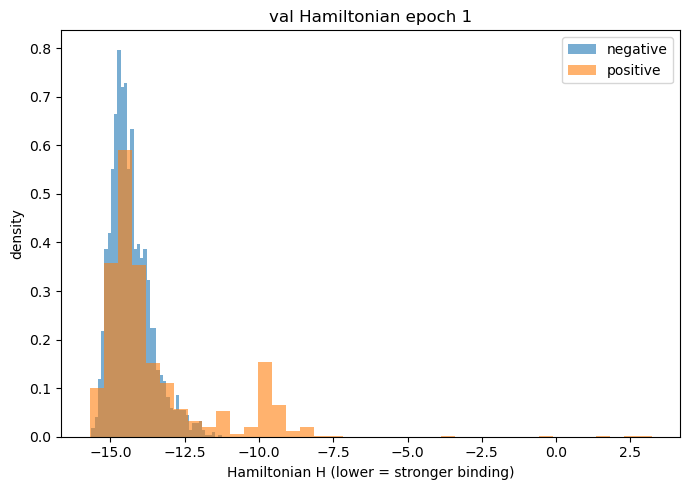

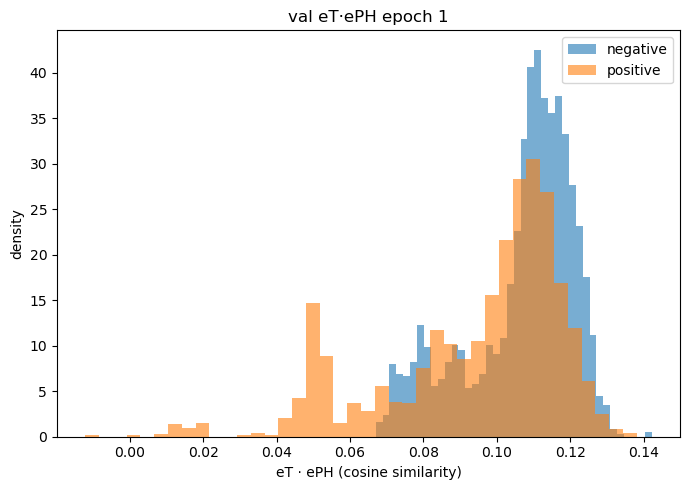

/tmp/ipykernel_2829197/2590628642.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


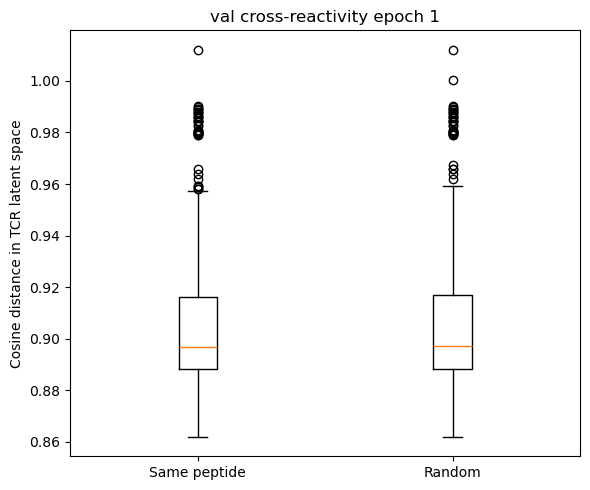

  [cross-reactivity] same_pep: n=1684, median=0.8966 | random: n=1944, median=0.8970
Epoch 2/20 | train_loss=-10.1626 | val_loss=1.4652 | val_auroc=0.5470 (cos) [H=0.4517, cos=0.5470] | val_auprc=0.6601 | val_f1=0.6603


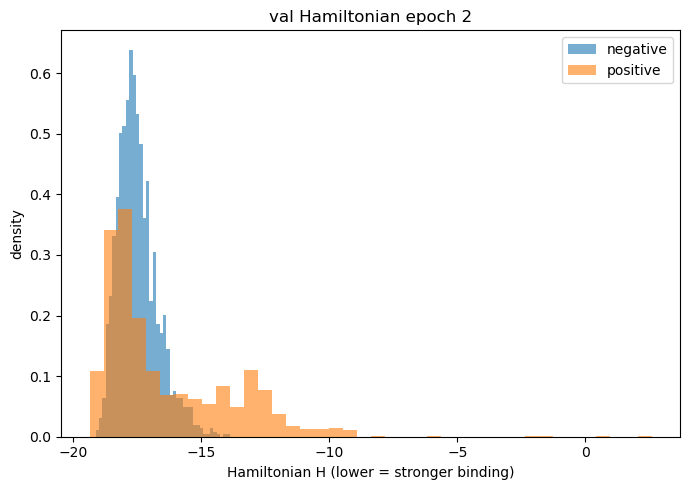

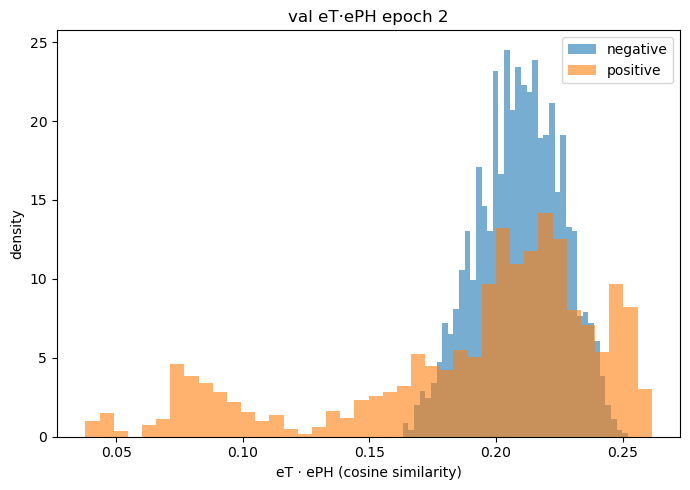

/tmp/ipykernel_2829197/2590628642.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


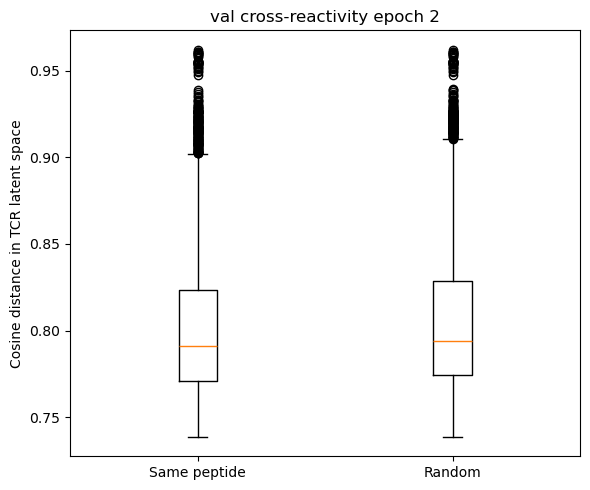

  [cross-reactivity] same_pep: n=1684, median=0.7913 | random: n=1944, median=0.7937
Epoch 3/20 | train_loss=-11.1420 | val_loss=4.3742 | val_auroc=0.6915 (cos) [H=0.4191, cos=0.6915] | val_auprc=0.7604 | val_f1=0.6603


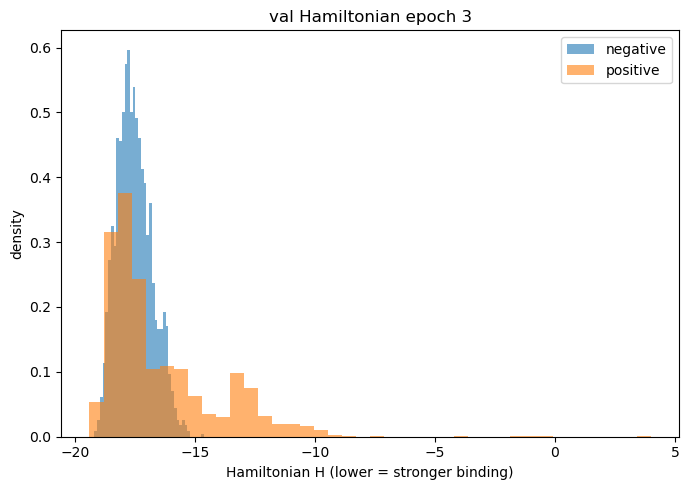

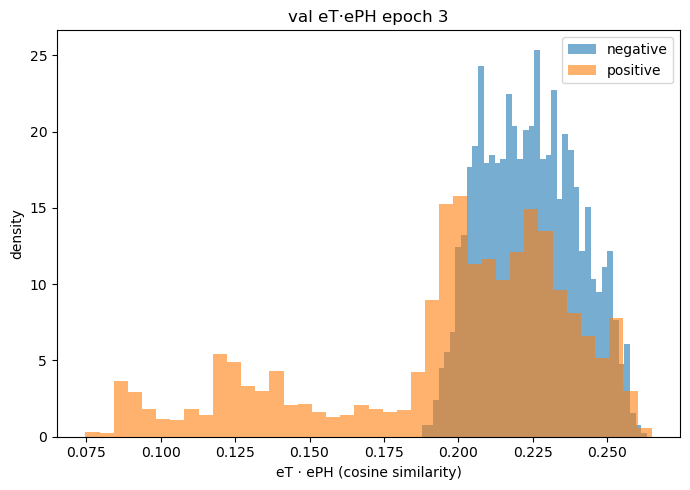

/tmp/ipykernel_2829197/2590628642.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


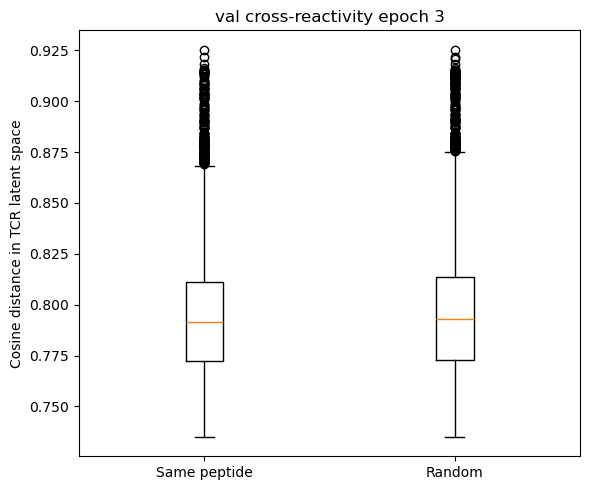

  [cross-reactivity] same_pep: n=1684, median=0.7915 | random: n=1944, median=0.7928
Epoch 4/20 | train_loss=-11.7477 | val_loss=4.2616 | val_auroc=0.7094 (cos) [H=0.3897, cos=0.7094] | val_auprc=0.7822 | val_f1=0.6663


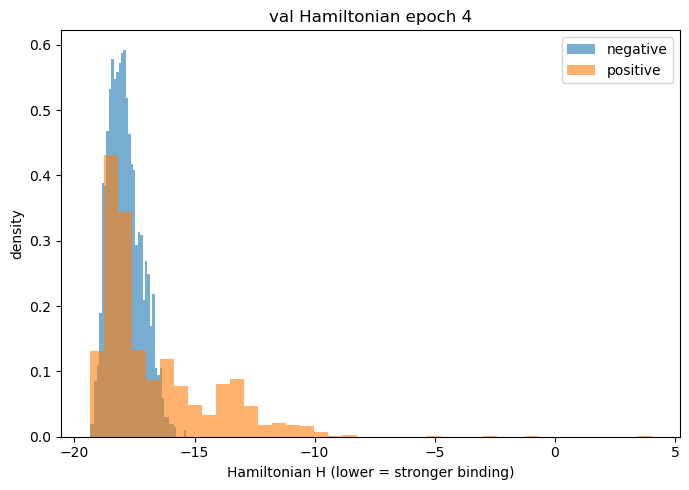

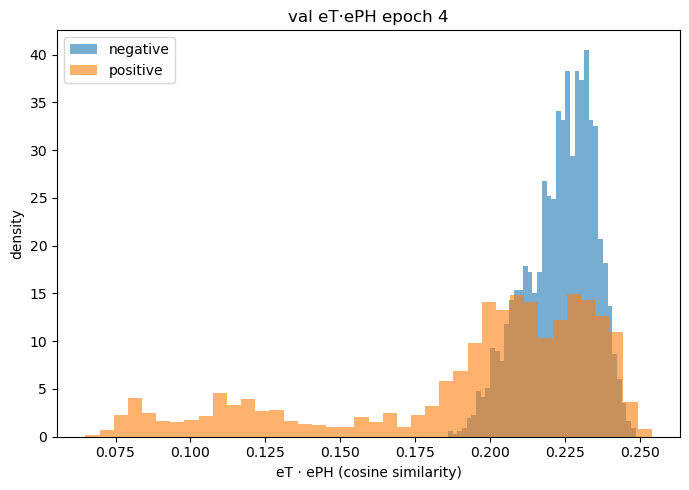

/tmp/ipykernel_2829197/2590628642.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


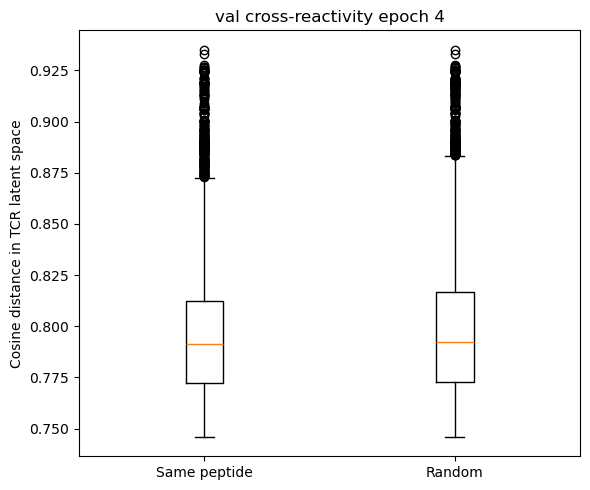

  [cross-reactivity] same_pep: n=1684, median=0.7912 | random: n=1944, median=0.7923
Epoch 5/20 | train_loss=-12.2264 | val_loss=0.6632 | val_auroc=0.5476 (cos) [H=0.4809, cos=0.5476] | val_auprc=0.6492 | val_f1=0.6603


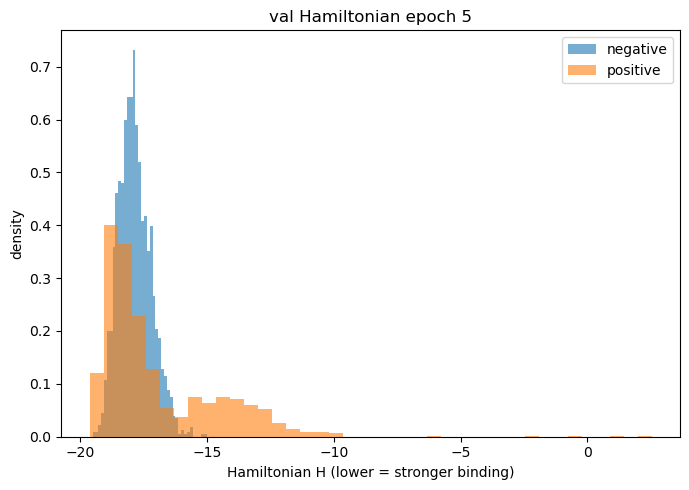

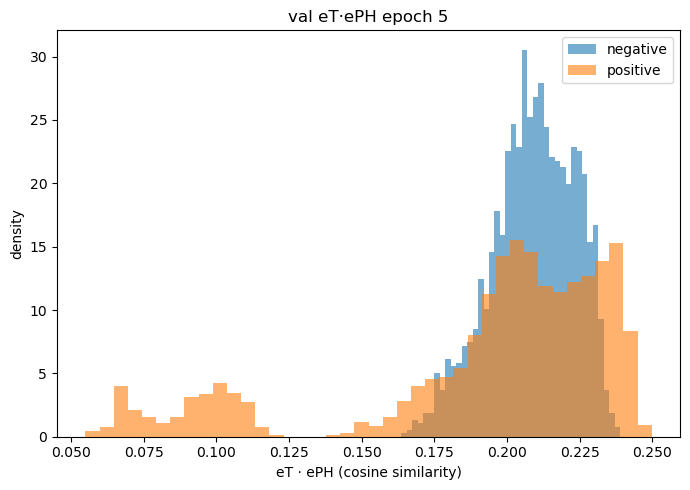

/tmp/ipykernel_2829197/2590628642.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


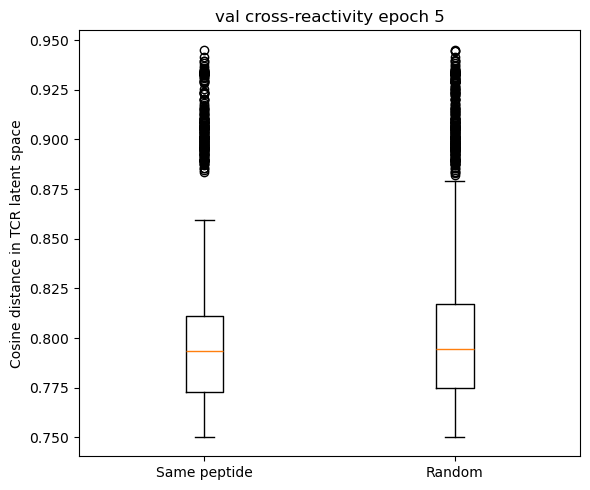

  [cross-reactivity] same_pep: n=1684, median=0.7933 | random: n=1944, median=0.7945
Epoch 6/20 | train_loss=-12.5968 | val_loss=-0.8331 | val_auroc=0.5682 (cos) [H=0.4555, cos=0.5682] | val_auprc=0.6733 | val_f1=0.6603


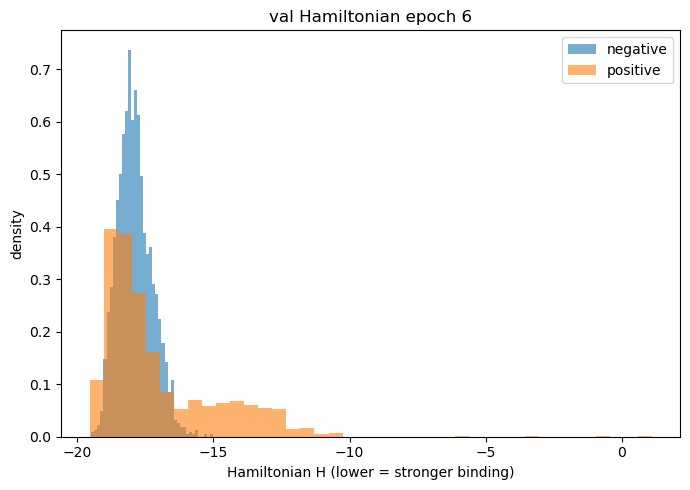

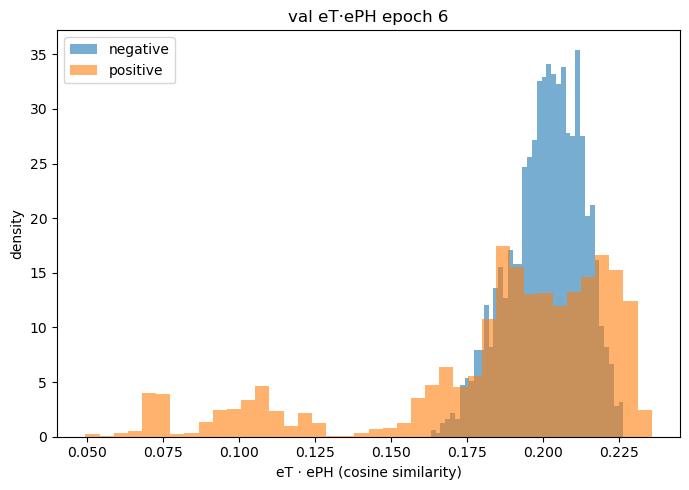

/tmp/ipykernel_2829197/2590628642.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


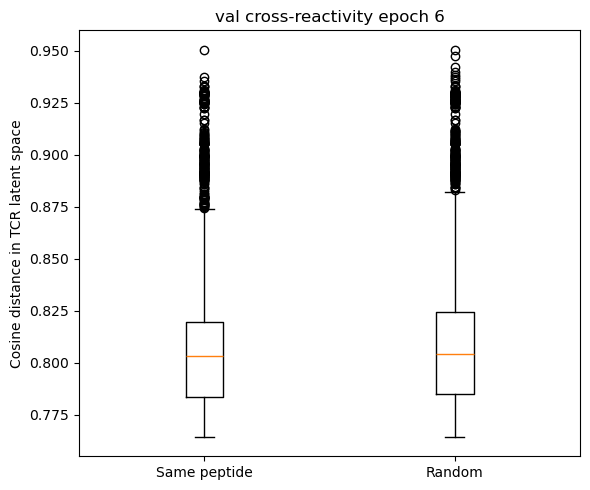

  [cross-reactivity] same_pep: n=1684, median=0.8031 | random: n=1944, median=0.8043
Epoch 7/20 | train_loss=-12.9133 | val_loss=-0.4707 | val_auroc=0.5653 (cos) [H=0.4432, cos=0.5653] | val_auprc=0.6760 | val_f1=0.6603


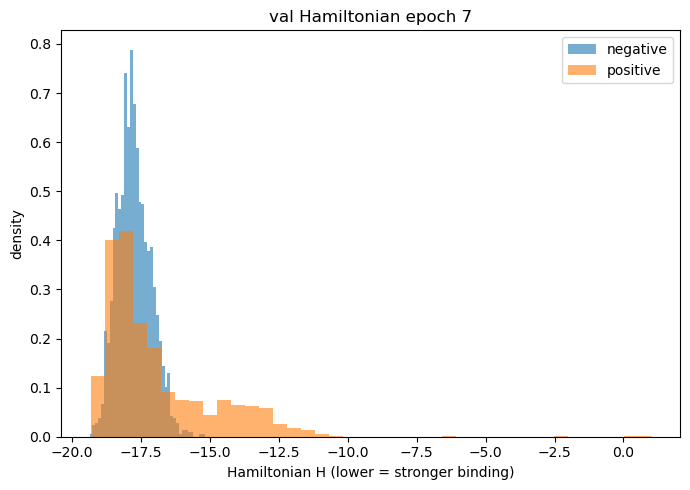

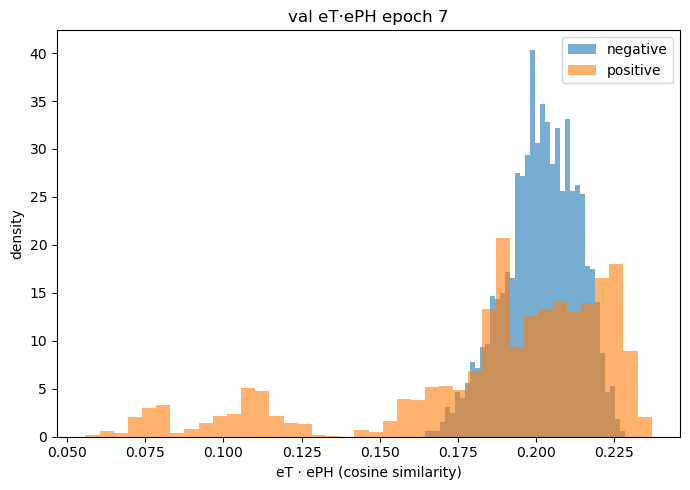

/tmp/ipykernel_2829197/2590628642.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


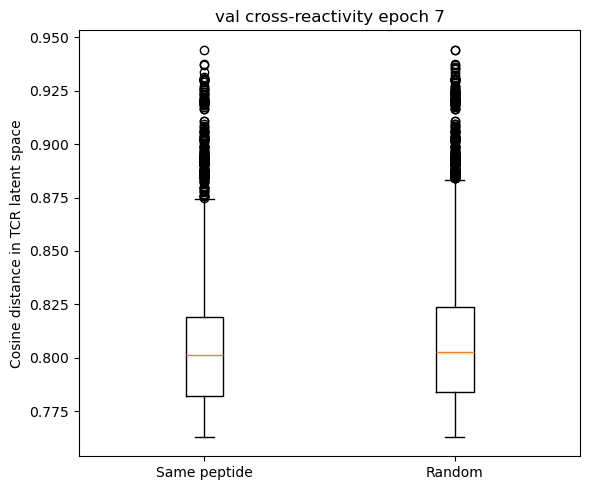

  [cross-reactivity] same_pep: n=1684, median=0.8011 | random: n=1944, median=0.8028
Epoch 8/20 | train_loss=-13.1568 | val_loss=1.3946 | val_auroc=0.6046 (cos) [H=0.4443, cos=0.6046] | val_auprc=0.7160 | val_f1=0.6603


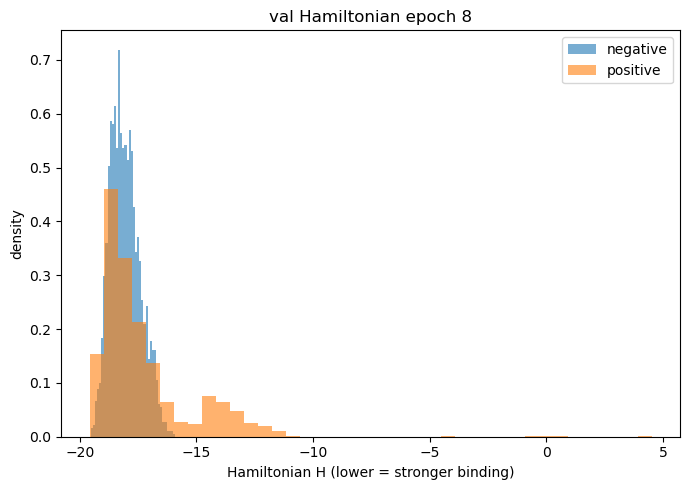

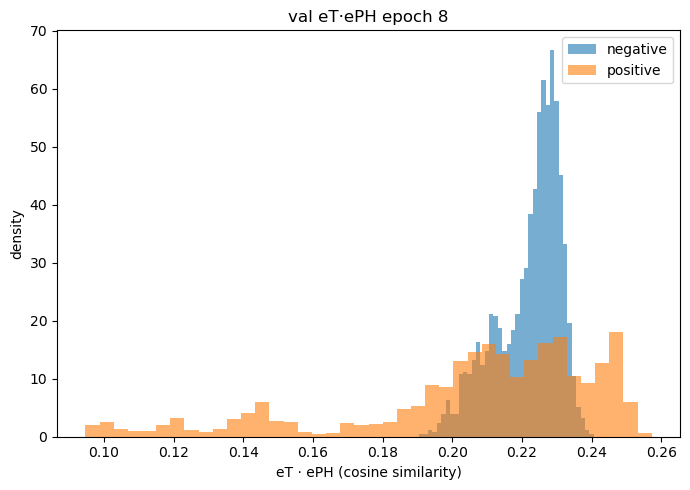

/tmp/ipykernel_2829197/2590628642.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


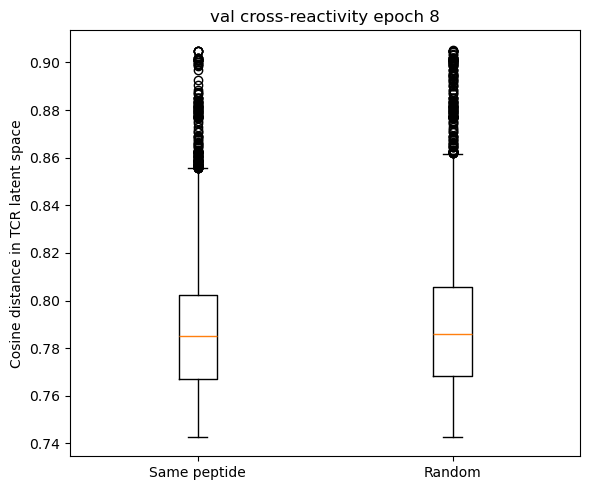

  [cross-reactivity] same_pep: n=1684, median=0.7852 | random: n=1944, median=0.7860
Epoch 9/20 | train_loss=-13.3982 | val_loss=0.1182 | val_auroc=0.5701 (cos) [H=0.4478, cos=0.5701] | val_auprc=0.6744 | val_f1=0.6603


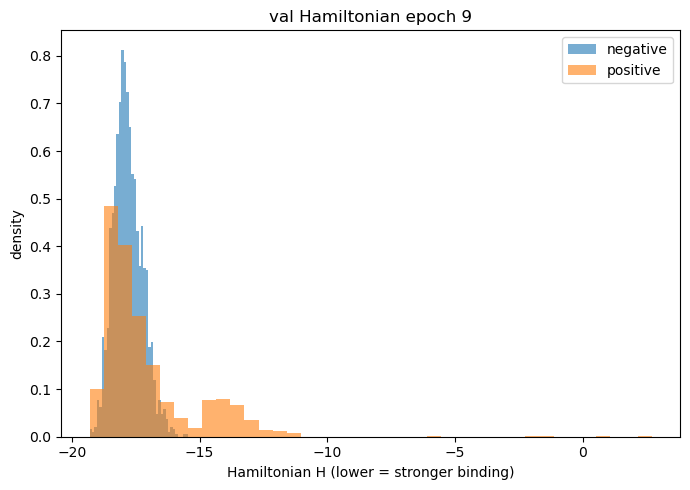

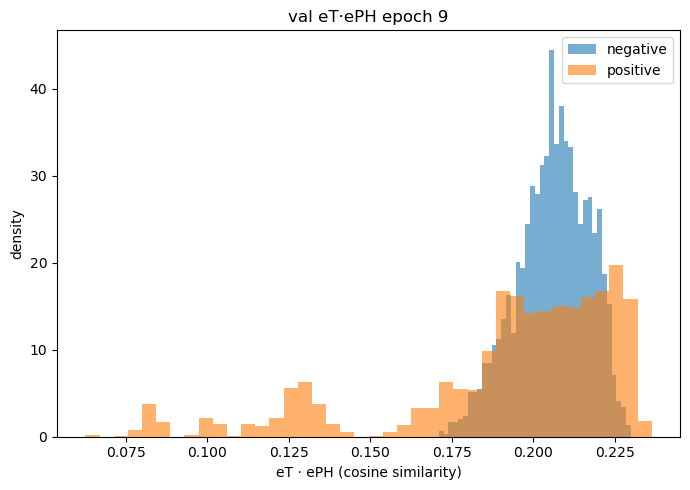

/tmp/ipykernel_2829197/2590628642.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


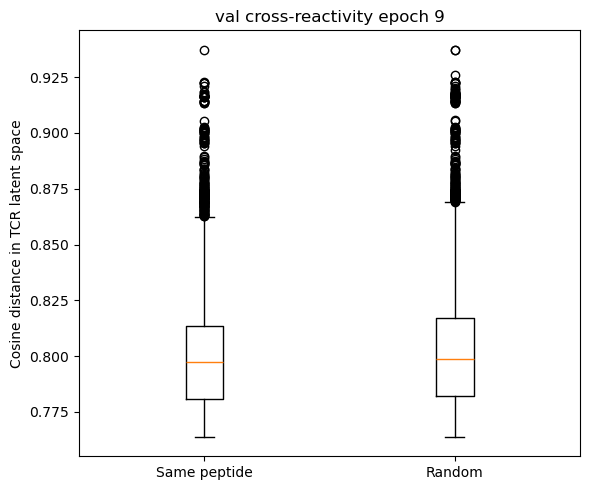

  [cross-reactivity] same_pep: n=1684, median=0.7975 | random: n=1944, median=0.7987
Epoch 10/20 | train_loss=-13.5701 | val_loss=-0.3231 | val_auroc=0.5334 (cos) [H=0.4991, cos=0.5334] | val_auprc=0.6580 | val_f1=0.6603


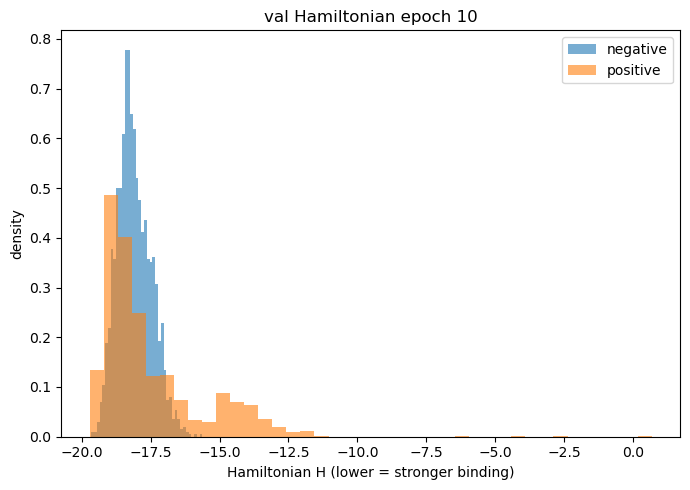

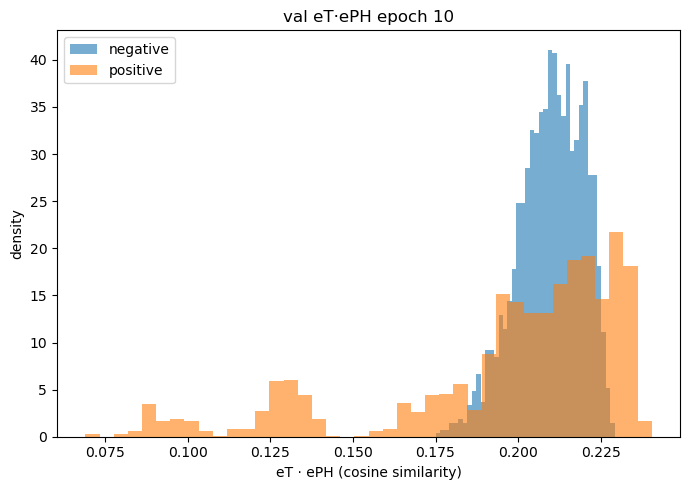

/tmp/ipykernel_2829197/2590628642.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


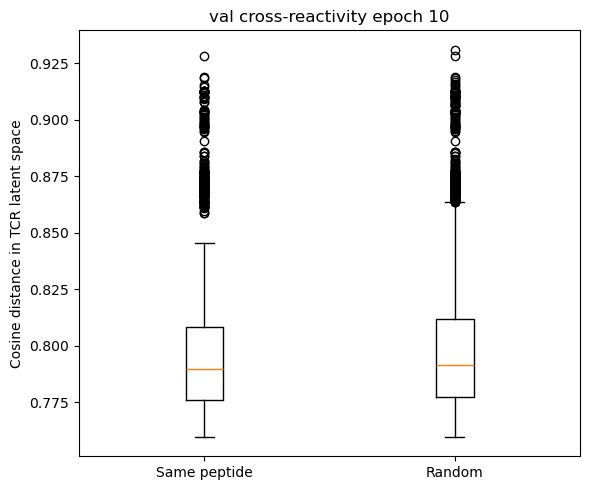

  [cross-reactivity] same_pep: n=1684, median=0.7898 | random: n=1944, median=0.7914
Epoch 11/20 | train_loss=-13.7123 | val_loss=1.8440 | val_auroc=0.6446 (cos) [H=0.4813, cos=0.6446] | val_auprc=0.7431 | val_f1=0.6603


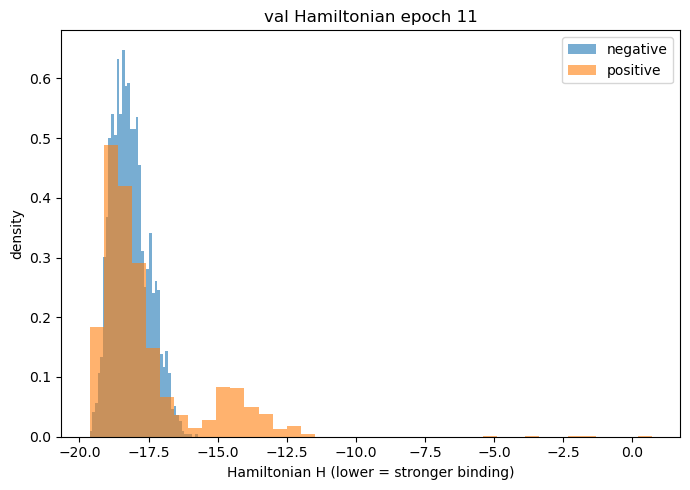

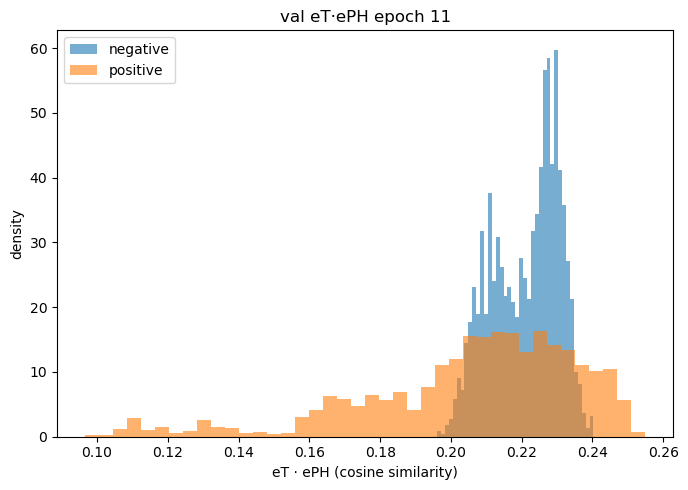

/tmp/ipykernel_2829197/2590628642.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


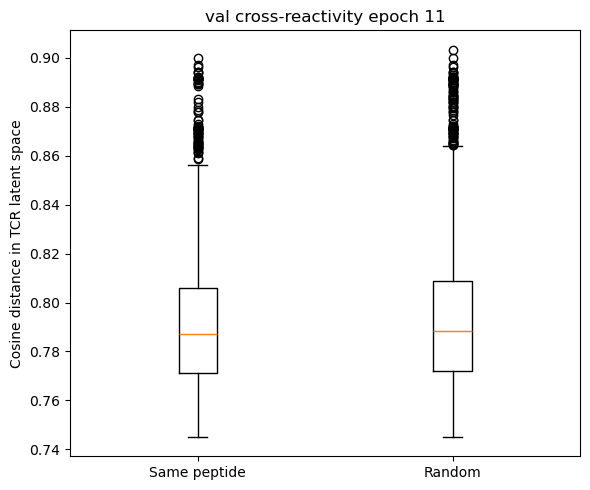

  [cross-reactivity] same_pep: n=1684, median=0.7873 | random: n=1944, median=0.7884
Epoch 12/20 | train_loss=-13.8161 | val_loss=-0.7553 | val_auroc=0.5864 (cos) [H=0.4922, cos=0.5864] | val_auprc=0.7004 | val_f1=0.6603


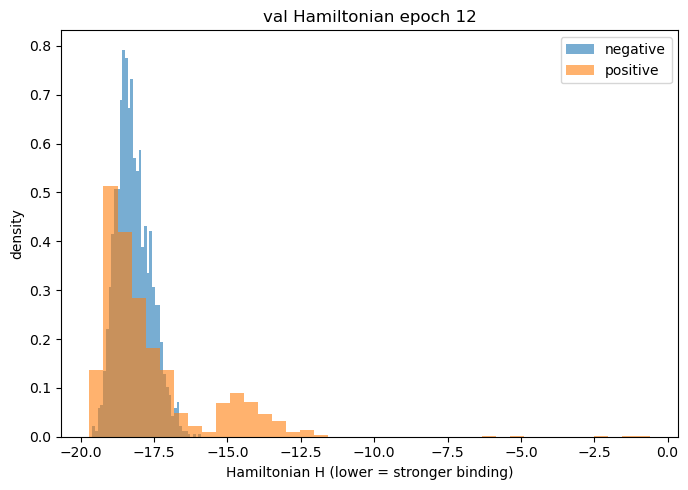

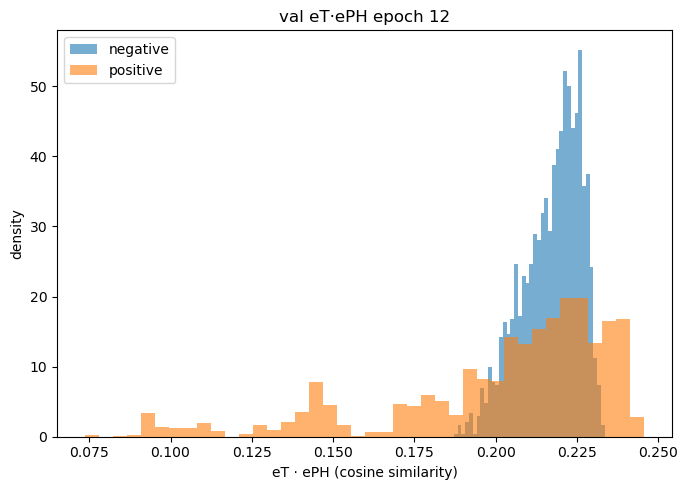

/tmp/ipykernel_2829197/2590628642.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


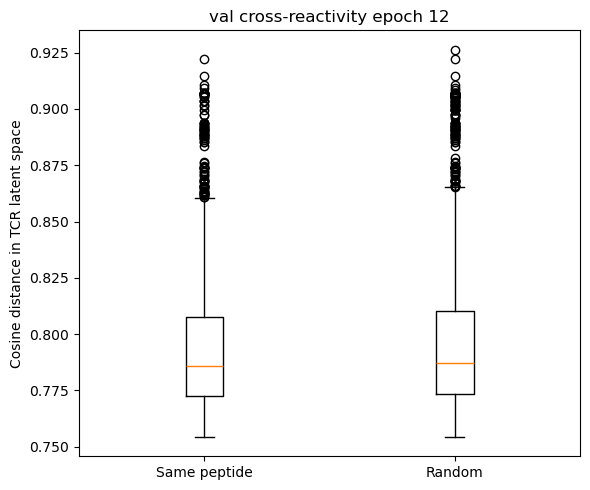

  [cross-reactivity] same_pep: n=1684, median=0.7859 | random: n=1944, median=0.7871
Epoch 13/20 | train_loss=-13.8938 | val_loss=-1.0144 | val_auroc=0.5811 (cos) [H=0.4840, cos=0.5811] | val_auprc=0.7004 | val_f1=0.6603


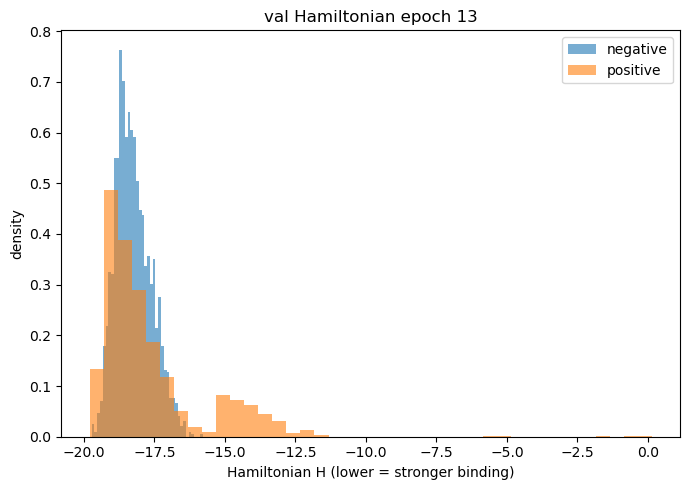

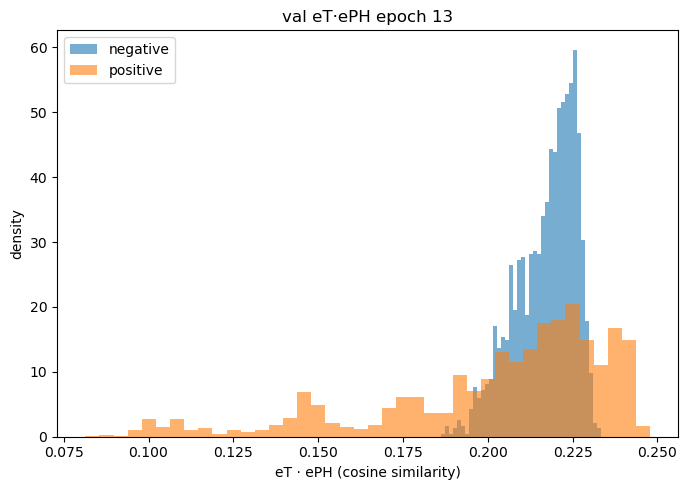

/tmp/ipykernel_2829197/2590628642.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


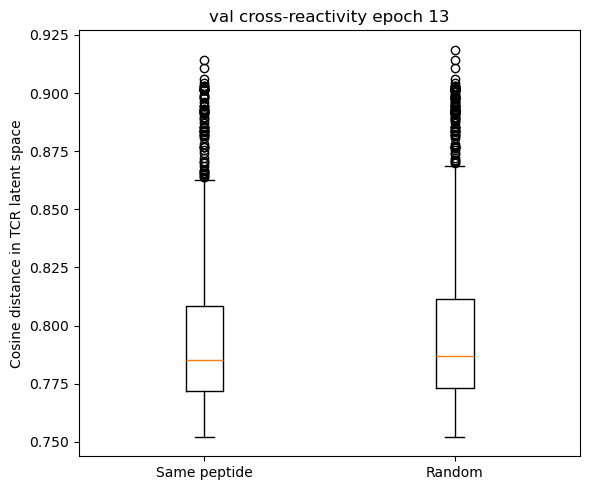

  [cross-reactivity] same_pep: n=1684, median=0.7852 | random: n=1944, median=0.7869
Epoch 14/20 | train_loss=-13.9807 | val_loss=-0.3875 | val_auroc=0.5998 (cos) [H=0.4735, cos=0.5998] | val_auprc=0.7135 | val_f1=0.6603


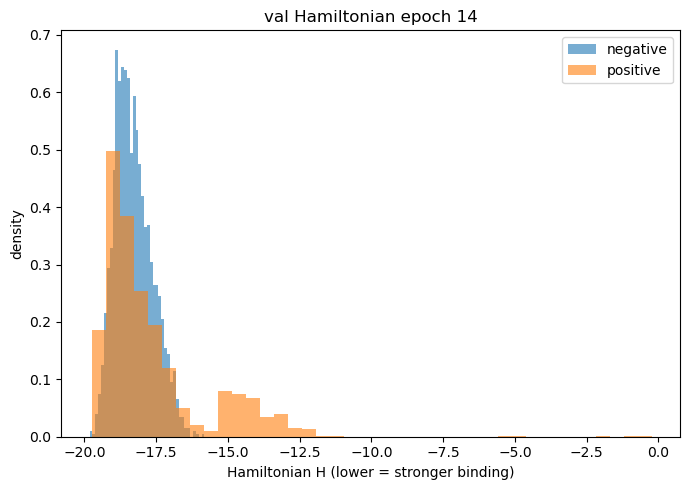

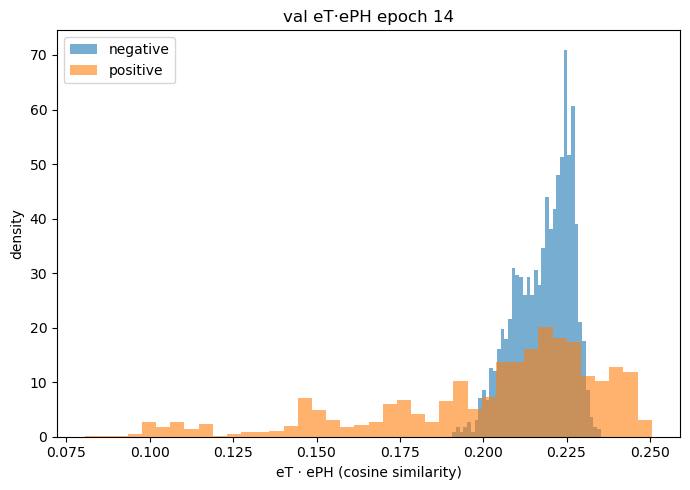

/tmp/ipykernel_2829197/2590628642.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


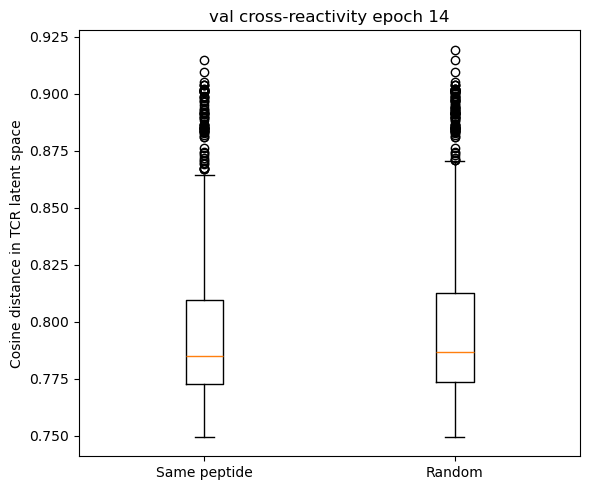

  [cross-reactivity] same_pep: n=1684, median=0.7851 | random: n=1944, median=0.7868
Early stopping at epoch 14

Best validation AUROC: 0.7093622685185185
Best config: {'rL': 8, 'rD': 16, 'd': 128, 'R_PH': 0.7, 'alpha': 1.0, 'beta': 25.0, 'delta': 1.0, 'gamma_var': 1.0, 'lr_tcr': 0.0001, 'lr_pmhc': 0.0001, 'weight_decay': 0.01, 'num_epochs': 20, 'patience': 10, 'loss_type': 'vicreg_hamiltonian_boltz_v2', 'early_stop_metric': 'val_auroc (best of H, cos)'}


In [34]:
all_results = []
best_result = None
best_score = -float("inf")  # tracking AUROC (higher is better)

for i, cfg in enumerate(search_space, 1):
    print(f"\n===== Full Hamiltonian run {i}/{len(search_space)} =====")
    print(cfg)

    result = run_experiment(
        train_loader=train_loader, val_loader=val_loader, device=device,
        rL=cfg["rL"], rD=cfg["rD"], d=cfg["d"],
        alpha=1.0, beta=25.0, delta=1.0,
        lr_tcr=cfg["lr_tcr"], lr_pmhc=cfg["lr_pmhc"],
        weight_decay=cfg["weight_decay"],
        num_epochs=20, patience=10,
    )

    val_auroc = result["best_state"]["val_auroc"]
    all_results.append((cfg, val_auroc, result))

    if val_auroc > best_score:
        best_score = val_auroc
        best_result = result

print("\nBest validation AUROC:", best_score)
print("Best config:", best_result["best_state"]["config"])


In [35]:
# save the best model
best_save_path = checkpoints_dir / "best_full_vicreg_hamiltonian_model.pt"

best_checkpoint = {
    "tcr_projection_state_dict": best_result["tcr_projection"].state_dict(),
    "pmhc_projection_state_dict": best_result["pmhc_projection"].state_dict(),
    "best_config": best_result["best_state"]["config"],
    "best_threshold": best_result["best_state"]["threshold"],
    "scoring_metric": best_result["best_state"]["scoring_metric"],
    "best_val_metrics": best_result["best_state"]["val_metrics"],
    "best_val_outputs": best_result["best_state"]["val_outputs"],
    "history": best_result["history"],
    "best_epoch": best_result["best_state"]["epoch"],
}

torch.save(best_checkpoint, best_save_path)
print(f"Best model saved to {best_save_path}")


Best model saved to /home/natasha/multimodal_model/models/checkpoints/best_full_vicreg_hamiltonian_model.pt


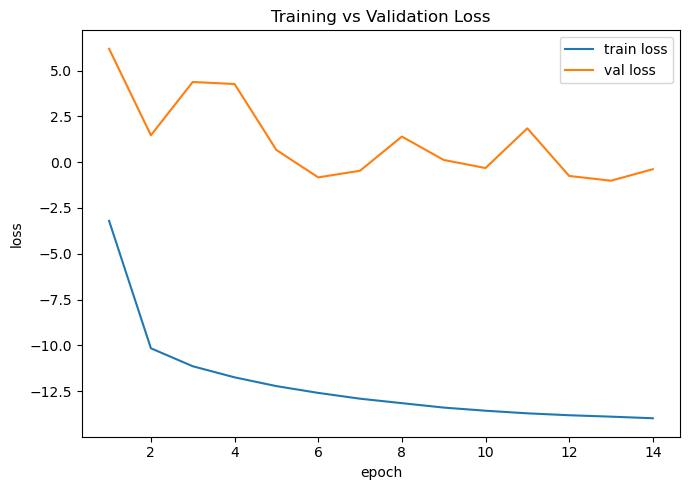

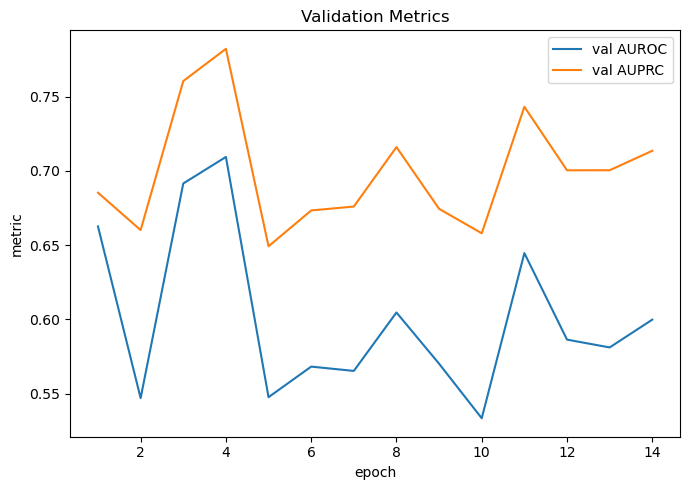


Best epoch: 4
Best scoring metric: cos
Best validation threshold: -0.21491238474845886
Best validation AUROC: 0.7093622685185185
Validation metrics: {'auroc': 0.7093622685185185, 'auroc_H': 0.3897191358024691, 'auroc_cos': 0.7093622685185185, 'scoring_metric': 'cos', 'auprc': 0.7821688900570788, 'val_loss': 4.261579923165497, 'threshold': -0.21491238474845886, 'f1': 0.666295574728639, 'accuracy': 0.6959939148073022, 'precision': 0.7258944815039418, 'recall': 0.6157407407407407}


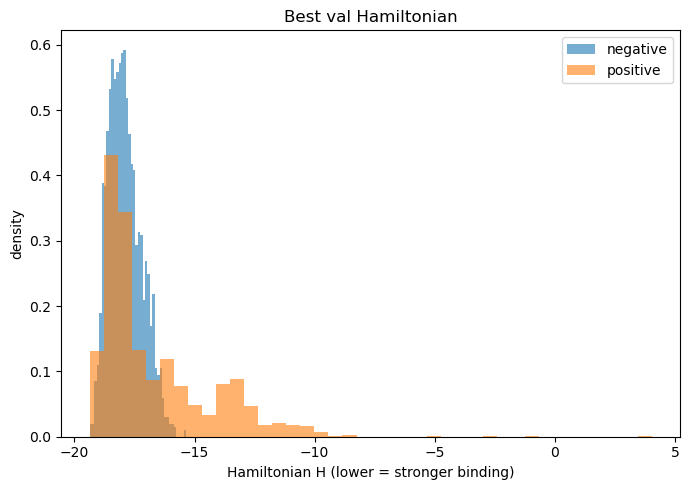

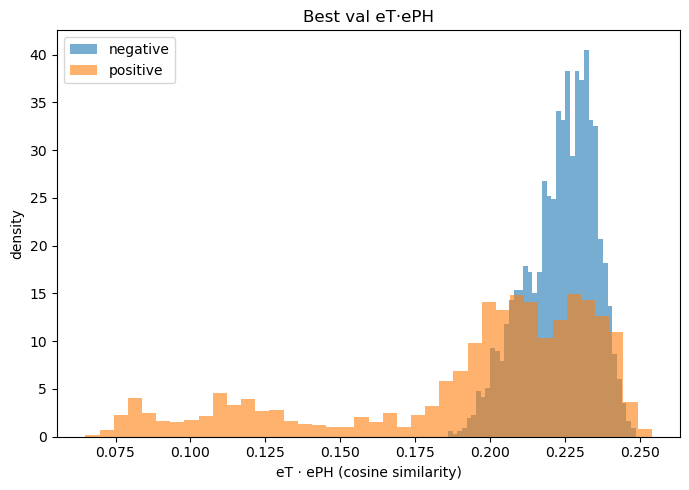

/tmp/ipykernel_2829197/2590628642.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


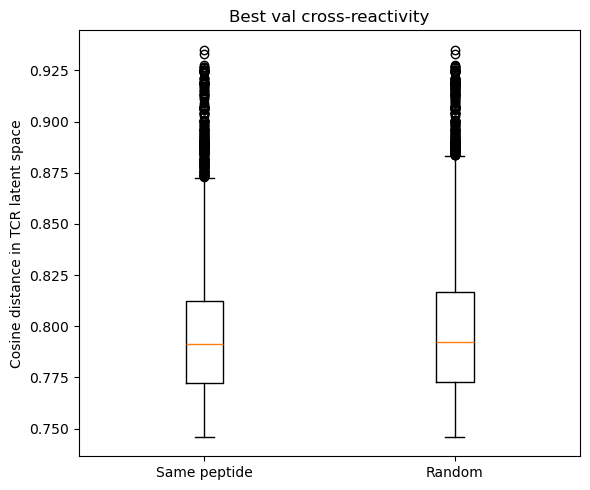

  [cross-reactivity] same_pep: n=1684, median=0.7912 | random: n=1944, median=0.7923


In [40]:
best_val = best_result["best_state"]["val_outputs"]
best_threshold = best_result["best_state"]["threshold"]

plot_training_history(best_result["history"])

print(f"\nBest epoch: {best_result['best_state']['epoch']}")
print(f"Best scoring metric: {best_result['best_state']['scoring_metric']}")
print(f"Best validation threshold: {best_threshold}")
print(f"Best validation AUROC: {best_result['best_state']['val_auroc']}")
print(f"Validation metrics: {best_result['best_state']['val_metrics']}")

# Plot best epoch diagnostics
plot_H_histogram(best_val["H"], best_val["labels"], title="Best val Hamiltonian")
plot_cosine_histogram(best_val["cos"], best_val["labels"], title="Best val eT·ePH")
plot_cross_reactivity(best_val["cos"], best_val["pair_ids"], best_val["labels"],
                       pep_lookup_val, title="Best val cross-reactivity")


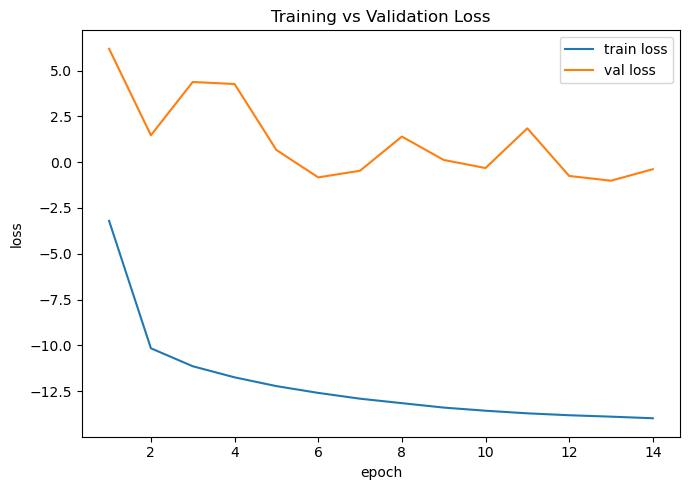

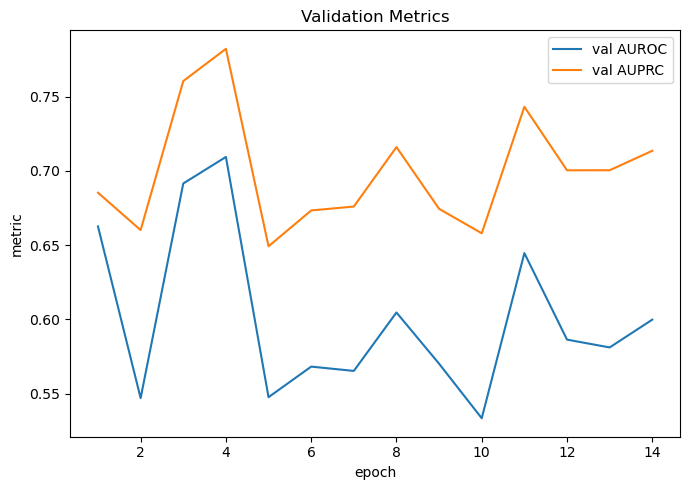

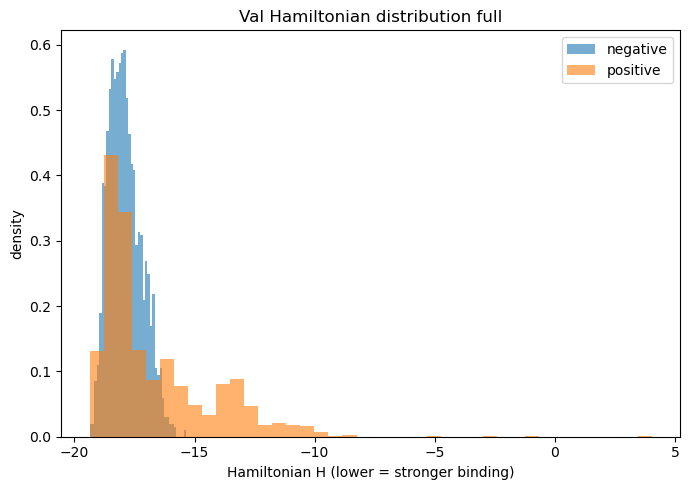

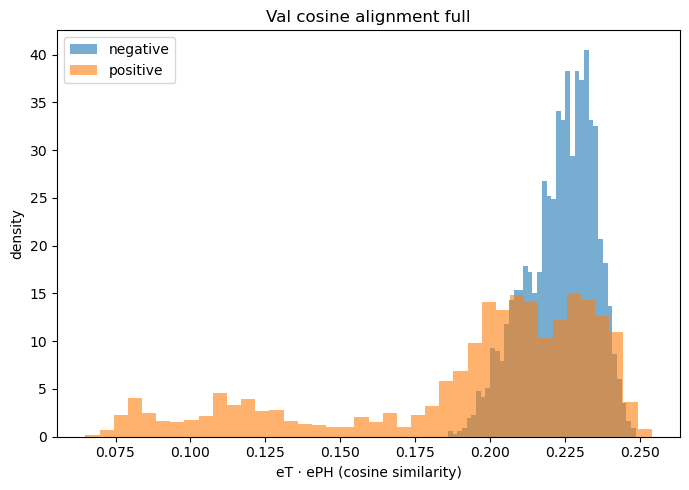

Best scoring metric: cos
Best validation threshold: -0.21491238474845886
Best validation AUROC: 0.7093622685185185
Validation metrics: {'auroc': 0.7093622685185185, 'auroc_H': 0.3897191358024691, 'auroc_cos': 0.7093622685185185, 'scoring_metric': 'cos', 'auprc': 0.7821688900570788, 'val_loss': 4.261579923165497, 'threshold': -0.21491238474845886, 'f1': 0.666295574728639, 'accuracy': 0.6959939148073022, 'precision': 0.7258944815039418, 'recall': 0.6157407407407407}


In [41]:
if best_result is None: 
    ckpt = torch.load(best_save_path, map_location=device)  # or map_location="cpu"

    # rebuild a minimal best_result-like structure for plotting/printing
    best_result = {
        "history": ckpt["history"],
        "best_state": {
            "threshold": ckpt["best_threshold"],
            "scoring_metric": ckpt.get("scoring_metric", "cos"),
            "val_metrics": ckpt["best_val_metrics"],
            "val_outputs": ckpt["best_val_outputs"],
            "epoch": ckpt["best_epoch"],
            "config": ckpt["best_config"],
            # optional fallback (if AUROC is inside val_metrics)
            "val_auroc": ckpt["best_val_metrics"].get("auroc", None),
        },
    }

best_val = best_result["best_state"]["val_outputs"]
best_threshold = best_result["best_state"]["threshold"]

plot_training_history(best_result["history"])
plot_H_histogram(best_val["H"], best_val["labels"], title="Val Hamiltonian distribution full")
plot_cosine_histogram(best_val["cos"], best_val["labels"], title="Val cosine alignment full")

print("Best scoring metric:", best_result["best_state"]["scoring_metric"])
print("Best validation threshold:", best_threshold)
print("Best validation AUROC:", best_result["best_state"]["val_auroc"])
print("Validation metrics:", best_result["best_state"]["val_metrics"])


g) Evaluate on test using best validation threshold

In [42]:
@torch.no_grad()
def evaluate_test_with_fixed_threshold(loader, tcr_projection, pmhc_projection,
                                       threshold, device, scoring_metric="cos", eps=1e-8):
    out = evaluate_loader(loader, tcr_projection, pmhc_projection, device, eps=eps)
    # Use the same scoring metric that was selected during validation
    scores = out[f"scores_{scoring_metric}"]
    labels = out["labels"]
    preds = (scores >= threshold).astype(int)
    out["test_metrics"] = {
        "auroc": roc_auc_score(labels, scores),
        "auroc_H": out["metrics"]["auroc_H"],
        "auroc_cos": out["metrics"]["auroc_cos"],
        "scoring_metric": scoring_metric,
        "auprc": average_precision_score(labels, scores),
        "f1": f1_score(labels, preds, zero_division=0),
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "confusion_matrix": confusion_matrix(labels, preds),
    }
    out["preds"] = preds
    return out


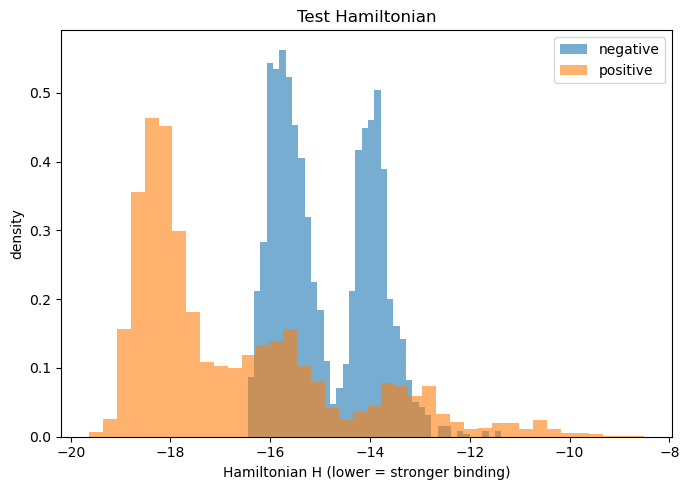

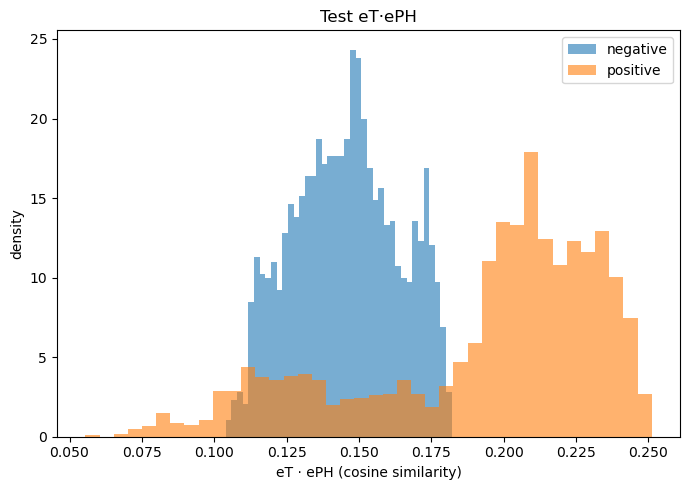

/tmp/ipykernel_2829197/2590628642.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


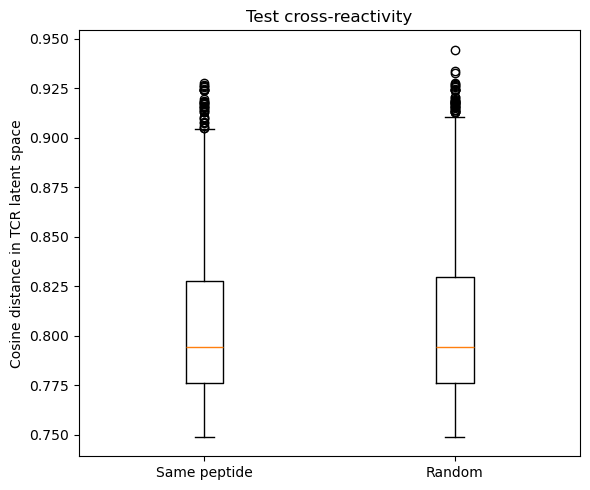

  [cross-reactivity] same_pep: n=1910, median=0.7940 | random: n=2182, median=0.7943

Test metrics: {'auroc': 0.1790417048579285, 'auroc_H': 0.7982074931255728, 'auroc_cos': 0.1790417048579285, 'scoring_metric': 'cos', 'auprc': 0.4296605604901296, 'f1': 0.5042918454935622, 'accuracy': 0.33715925394548063, 'precision': 0.41348973607038125, 'recall': 0.6461961503208066, 'confusion_matrix': array([[   0, 2000],
       [ 772, 1410]])}
Test confusion matrix:
 [[   0 2000]
 [ 772 1410]]


In [43]:
best_scoring_metric = best_result["best_state"]["scoring_metric"]

test_out = evaluate_test_with_fixed_threshold(
    loader=test_loader,
    tcr_projection=best_result["tcr_projection"],
    pmhc_projection=best_result["pmhc_projection"],
    threshold=best_threshold,
    device=device,
    scoring_metric=best_scoring_metric,
)

# Test plots — raw H and eT·ePH, plus cross-reactivity
plot_H_histogram(test_out["H"], test_out["labels"], title="Test Hamiltonian")
plot_cosine_histogram(test_out["cos"], test_out["labels"], title="Test eT·ePH")
plot_cross_reactivity(test_out["cos"], test_out["pair_ids"], test_out["labels"],
                       pep_lookup_test, title="Test cross-reactivity")

print("\nTest metrics:", test_out["test_metrics"])
print("Test confusion matrix:\n", test_out["test_metrics"]["confusion_matrix"])
